# SynapseML LightGBM — Clean & Cluster-Optimized Notebook + Best Iteration Export

Notebook này dùng để phát hiện **data drift/anomaly theo batch** bằng cách:

- `label = 1`: batch hiện tại cần kiểm tra.
- `label = 0`: các batch lịch sử dùng để so sánh.
- Train **SynapseML LightGBM** để phân biệt 2 nhóm dữ liệu.
- Dùng **AUC** để đo mức độ khác nhau giữa batch hiện tại và lịch sử.

Thiết kế vẫn giữ các tối ưu chính của notebook cũ:

1. Không dùng `orderBy(rand()).limit()` trên toàn bộ batch lớn.
2. Sampling theo `processing_date_hour` bằng candidate sampling trước, rồi mới random sort + limit.
3. Spark split theo label bằng hash/window để gần giống `train_test_split(..., stratify=y)`.
4. Cache/persist các DataFrame dùng lại nhiều lần.
5. SynapseML profile tối ưu cho cụm `2 executors x 6 cores`, `task.cpus = 3`, `numTasks = 4`, `numThreads = 3`.
6. Không bật SHAP trong Optuna vì rất nặng; chỉ bật ở final model nếu cần.

7. Lưu `best_iteration`, `best_iteration_source`, `booster_total_iterations` để dùng lại `numIterations` cố định trong production.


## 1. Import libraries


In [1]:
import os
import json
import math
import random
import time
import gc
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from sklearn.metrics import roc_auc_score, classification_report

from IPython.display import display

from pyspark import StorageLevel
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.types import StructType, StructField, DoubleType, LongType
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array

from synapse.ml.lightgbm import LightGBMClassifier

print("Optuna version:", optuna.__version__)


Optuna version: 4.8.0


## 2. Configuration

Bạn chỉ cần sửa các biến trong cell này khi đổi dữ liệu, batch target hoặc cấu hình cluster.


In [2]:
# ============================================================
# Reproducibility
# ============================================================
RANDOM_STATE = 42

# ============================================================
# Input / output
# ============================================================
# Dữ liệu được đọc từ bảng Iceberg/Lakehouse thông qua Trino JDBC,
# thay vì đọc trực tiếp file Parquet.
#
# Có thể override bằng environment variables khi chạy notebook/container:
#   TRINO_HOST, TRINO_PORT, TRINO_USER, TRINO_PASSWORD
#   TRINO_CATALOG, TRINO_SCHEMA, TRINO_TABLE, TRINO_TABLE_FQN
#   TRINO_READ_MODE, TRINO_CUSTOM_SQL
TRINO_HOST = os.getenv("TRINO_HOST", "trino")
TRINO_PORT = int(os.getenv("TRINO_PORT", "8080"))
TRINO_USER = os.getenv("TRINO_USER", "admin")
TRINO_PASSWORD = os.getenv("TRINO_PASSWORD", "")

TRINO_CATALOG = os.getenv("TRINO_CATALOG", "iceberg")
TRINO_SCHEMA = os.getenv("TRINO_SCHEMA", "silver")

# Đổi tên bảng này cho đúng với bảng Silver của bạn nếu khác.
# Ví dụ thường gặp trong DataGate: "tlc_trip_record".
TRINO_TABLE = os.getenv("TRINO_TABLE", "tlc_trip_record")

# Nếu bảng/cột cần quote đặc biệt, có thể truyền sẵn FQN qua env:
#   TRINO_TABLE_FQN='"iceberg"."silver"."tlc_trip_record"'
TRINO_TABLE_FQN = os.getenv(
    "TRINO_TABLE_FQN",
    f"{TRINO_CATALOG}.{TRINO_SCHEMA}.{TRINO_TABLE}",
)

# Ví dụ TRINO_JDBC_URL_EXTRA="?SSL=true" nếu Trino bật SSL.
TRINO_JDBC_URL_EXTRA = os.getenv("TRINO_JDBC_URL_EXTRA", "")
TRINO_JDBC_URL = (
    f"jdbc:trino://{TRINO_HOST}:{TRINO_PORT}/"
    f"{TRINO_CATALOG}/{TRINO_SCHEMA}{TRINO_JDBC_URL_EXTRA}"
)

TRINO_DRIVER = os.getenv("TRINO_DRIVER", "io.trino.jdbc.TrinoDriver")
TRINO_FETCH_SIZE = int(os.getenv("TRINO_FETCH_SIZE", "10000"))

# Cách đọc dữ liệu từ Trino:
# - "target_and_history": chỉ đọc target batch + các batch lịch sử cần so sánh.
# - "full_table": đọc toàn bộ bảng.
# - "custom_sql": dùng TRINO_CUSTOM_SQL bên dưới.
TRINO_READ_MODE = os.getenv("TRINO_READ_MODE", "target_and_history").strip().lower()
TRINO_CUSTOM_SQL = os.getenv("TRINO_CUSTOM_SQL", "").strip() or None

# Nơi lưu CSV kết quả: Optuna trials, feature importance, AUC monitoring, ...
OUTPUT_DIR = "/opt/spark/workspace/output/synapseml_experiment_silver_yellow_tripdata"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# Target batch cần kiểm tra
# ============================================================
# Batch hiện tại sẽ được gán label = 1.
TARGET_PROCESSING_DATE_HOUR = pd.Timestamp("2025-01-15 12:00:00")

# Vì pipeline của bạn xử lý 12h/lần, batch liền trước là target - 12h.
PREVIOUS_BATCH_OFFSET = pd.Timedelta(hours=12)

# Các batch lịch sử bổ sung được gán label = 0.
# Bạn có thể thêm/bớt offset tùy dữ liệu thực tế.
HISTORY_OFFSETS = [
    pd.Timedelta(days=1),
    pd.Timedelta(days=7),
    pd.Timedelta(days=14),
]

# ============================================================
# Sampling theo từng processing_date_hour
# ============================================================
# Mỗi batch chỉ lấy tối đa số dòng này để LightGBM chạy nhanh hơn.
TARGET_SAMPLE_PER_GROUP = 10_000
MIN_ROWS_PER_GROUP = 100

# Sampling candidate lấy dư một chút trước khi limit.
# Ví dụ cần 10,000 dòng, candidate sẽ khoảng 16,000 dòng nếu batch đủ lớn.
# OVERSAMPLE_FACTOR = 1.6

# ============================================================
# Train / validation / test split
# ============================================================
TEST_SIZE = 0.15
VALID_SIZE = 0.15

# ============================================================
# Optuna / LightGBM
# ============================================================
RUN_OPTUNA = True
N_TRIALS = 100
DEBUG_TRIAL_ERRORS = False

# SynapseML LightGBM sẽ train tối đa N_ESTIMATORS_MAX vòng.
# earlyStoppingRound sẽ dừng sớm nếu validation AUC không cải thiện.
N_ESTIMATORS_MAX = 2000
EARLY_STOPPING_ROUNDS = 100

# SHAP rất nặng trong SynapseML.
# Khuyến nghị: Optuna luôn không dùng SHAP; final model mới bật nếu cần giải thích.
RUN_FINAL_SHAP = True
SHAP_SAMPLE_SIZE = 3000

# ============================================================
# Optional experiments / monitoring
# ============================================================
RUN_SYNTHETIC_EXPERIMENTS = False
RUN_BATCH_MONITORING = False
RUN_BATCH_SHAP = False

# Batch monitoring range: chỉ dùng khi RUN_BATCH_MONITORING=True.
# BATCH_START = pd.Timestamp("2025-01-20 00:00:00")
# BATCH_END = pd.Timestamp("2025-01-31 12:00:00")
# BATCH_FREQ = "12h"

# Empirical p-value config cho chuỗi AUC.
# MIN_HISTORY_POINTS = 20
# ROLLING_WINDOW = None
# ALPHA = 0.05

# ============================================================
# SynapseML LightGBM cluster profile
# ------------------------------------------------------------
# Profile cho cụm 2 workers, mỗi worker 6 cores / khoảng 12-14GB RAM:
# spark.executor.instances = 2
# spark.executor.cores     = 6
# spark.task.cpus          = 3
# available task slots     = 2 * floor(6/3) = 4
# => LightGBM numTasks=4, numThreads=3, data repartition(4)
# ============================================================
LGBM_NUM_TASKS = 4
LGBM_NUM_THREADS = 3
LGBM_NUM_PARTITIONS = 4

# Spark preprocessing/shuffle profile.
# 4 task slots * 3 waves = 12 partitions.
SPARK_SQL_SHUFFLE_PARTITIONS = 12
SPARK_DEFAULT_PARALLELISM = 12

# Khi chạy nhiều Optuna trials trong notebook, không cố định port để tránh lỗi port busy.
USE_FIXED_PORTS = False

print("TRINO_JDBC_URL:", TRINO_JDBC_URL)
print("TRINO_TABLE_FQN:", TRINO_TABLE_FQN)
print("TRINO_READ_MODE:", TRINO_READ_MODE)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("TARGET_PROCESSING_DATE_HOUR:", TARGET_PROCESSING_DATE_HOUR)
print("TARGET_SAMPLE_PER_GROUP:", TARGET_SAMPLE_PER_GROUP)
print("RUN_OPTUNA:", RUN_OPTUNA, "| N_TRIALS:", N_TRIALS)
print("SynapseML profile:", {
    "numTasks": LGBM_NUM_TASKS,
    "numThreads": LGBM_NUM_THREADS,
    "partitions": LGBM_NUM_PARTITIONS,
    "shuffle_partitions": SPARK_SQL_SHUFFLE_PARTITIONS,
})

DATA_PATH: /opt/spark/workspace/input/data/silver_yellow_tripdata_2025-01.parquet
OUTPUT_DIR: /opt/spark/workspace/output/synapseml_experiment_silver_yellow_tripdata
TARGET_PROCESSING_DATE_HOUR: 2025-01-15 12:00:00
TARGET_SAMPLE_PER_GROUP: 10000
RUN_OPTUNA: True | N_TRIALS: 100
SynapseML profile: {'numTasks': 4, 'numThreads': 3, 'partitions': 4, 'shuffle_partitions': 12}


## 3. Start Spark session

Cell này tạo Spark session theo profile đã tối ưu. Nếu bạn chạy trong môi trường đã có Spark session, vẫn có thể giữ cell này; Spark sẽ trả về session hiện tại nếu tồn tại.

Để đọc Trino qua JDBC, đảm bảo Trino JDBC driver đã nằm trong classpath của Spark trước khi chạy cell load dữ liệu.

In [3]:
spark = (
    SparkSession.builder
    .appName("SynapseML LightGBM Batch Drift Detection - Clean")
    .master("spark://spark-master:7077")
    .config("spark.executor.instances", "2")
    .config("spark.executor.cores", "6")
    .config("spark.executor.memory", "10g")
    .config("spark.task.cpus", str(LGBM_NUM_THREADS))
    .config("spark.sql.shuffle.partitions", str(SPARK_SQL_SHUFFLE_PARTITIONS))
    .config("spark.default.parallelism", str(SPARK_DEFAULT_PARALLELISM))
    .config("spark.dynamicAllocation.enabled", "false")
    # .config("spark.speculation", "false")
    # .config("spark.scheduler.mode", "FIFO")
    # .config("spark.python.worker.reuse", "true")
    # .config("spark.executorEnv.OMP_NUM_THREADS", str(LGBM_NUM_THREADS))
    # .config("spark.executorEnv.MKL_NUM_THREADS", "1")
    # .config("spark.executorEnv.OPENBLAS_NUM_THREADS", "1")
    # .config("spark.executorEnv.NUMEXPR_NUM_THREADS", "1")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

conf = spark.sparkContext.getConf()


def get_conf_int(key, default):
    """Đọc Spark conf dạng int; nếu thiếu hoặc lỗi thì dùng default."""
    try:
        return int(conf.get(key, str(default)))
    except Exception:
        return int(default)


executor_instances = get_conf_int("spark.executor.instances", 2)
executor_cores = get_conf_int("spark.executor.cores", 6)
task_cpus = get_conf_int("spark.task.cpus", LGBM_NUM_THREADS)
available_task_slots = executor_instances * (executor_cores // task_cpus)

print("Spark application:", spark.sparkContext.appName)
print("Spark master:", spark.sparkContext.master)
print("executor.instances:", executor_instances)
print("executor.cores:", executor_cores)
print("spark.task.cpus:", task_cpus)
print("Available Spark task slots:", available_task_slots)
print("Expected SynapseML numTasks:", LGBM_NUM_TASKS)
print("spark.sql.shuffle.partitions:", conf.get("spark.sql.shuffle.partitions"))
print("spark.default.parallelism:", conf.get("spark.default.parallelism"))

if available_task_slots < LGBM_NUM_TASKS:
    raise ValueError(
        f"Spark chỉ có {available_task_slots} task slots nhưng LGBM_NUM_TASKS={LGBM_NUM_TASKS}. "
        "Hãy giảm LGBM_NUM_TASKS, giảm spark.task.cpus hoặc tăng executor cores."
    )


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/11 23:13:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark application: SynapseML LightGBM Batch Drift Detection - Clean
Spark master: spark://spark-master:7077
executor.instances: 2
executor.cores: 6
spark.task.cpus: 3
Available Spark task slots: 4
Expected SynapseML numTasks: 4
spark.sql.shuffle.partitions: 12
spark.default.parallelism: 12


## 4. Load Silver data from Trino

Notebook đọc dữ liệu từ bảng Lakehouse/Iceberg thông qua Trino JDBC.

Lưu ý: Spark cần có Trino JDBC driver trong classpath, ví dụ mount file `trino-jdbc-*.jar` vào `/opt/spark/jars` của driver/executor container hoặc cấu hình `spark.jars.packages` khi môi trường cho phép tải package.

In [4]:
def build_trino_source_sql():
    """
    Tạo SQL đọc dữ liệu từ Trino.

    Mặc định chỉ đọc các batch cần cho target + history để giảm dữ liệu kéo qua JDBC.
    Nếu cần đọc toàn bảng, đặt:
        TRINO_READ_MODE = "full_table"

    Nếu muốn tự kiểm soát SQL, đặt:
        TRINO_READ_MODE = "custom_sql"
        TRINO_CUSTOM_SQL = "SELECT ..."
    """
    if TRINO_READ_MODE == "custom_sql":
        if not TRINO_CUSTOM_SQL:
            raise ValueError("TRINO_READ_MODE='custom_sql' nhưng TRINO_CUSTOM_SQL đang rỗng.")
        return TRINO_CUSTOM_SQL.rstrip(";")

    if TRINO_READ_MODE == "full_table":
        return f"SELECT * FROM {TRINO_TABLE_FQN}"

    if TRINO_READ_MODE != "target_and_history":
        raise ValueError(
            "TRINO_READ_MODE không hợp lệ. "
            "Hãy dùng một trong: 'target_and_history', 'full_table', 'custom_sql'."
        )

    target_hour = pd.Timestamp(TARGET_PROCESSING_DATE_HOUR)
    comparison_hours = [target_hour - PREVIOUS_BATCH_OFFSET]
    comparison_hours += [
        target_hour - offset
        for offset in HISTORY_OFFSETS
    ]

    processing_hours = sorted(set([target_hour] + comparison_hours))
    hour_literals = ",\n        ".join(
        f"TIMESTAMP '{hour.strftime('%Y-%m-%d %H:%M:%S')}'"
        for hour in processing_hours
    )

    return f"""
SELECT *
FROM {TRINO_TABLE_FQN}
WHERE processing_date_hour IN (
        {hour_literals}
)
""".strip()


TRINO_SOURCE_SQL = build_trino_source_sql()

print("SQL used to load data from Trino:")
print(TRINO_SOURCE_SQL)

reader = (
    spark.read
    .format("jdbc")
    .option("url", TRINO_JDBC_URL)
    .option("driver", TRINO_DRIVER)
    .option("query", TRINO_SOURCE_SQL)
    .option("user", TRINO_USER)
    .option("fetchsize", TRINO_FETCH_SIZE)
)

# Chỉ truyền password khi có cấu hình, để vẫn chạy được với Trino no-auth.
if TRINO_PASSWORD:
    reader = reader.option("password", TRINO_PASSWORD)

df_raw = reader.load()

# Chuẩn hóa tên cột về lowercase để các cell phía sau dùng thống nhất.
for old_col in df_raw.columns:
    new_col = old_col.lower()
    if old_col != new_col:
        df_raw = df_raw.withColumnRenamed(old_col, new_col)

# Ép các cột thời gian quan trọng về timestamp để filter batch ổn định.
for ts_col in [
    "date_hour",
    "processing_date_hour",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
]:
    if ts_col in df_raw.columns:
        df_raw = df_raw.withColumn(ts_col, F.col(ts_col).cast("timestamp"))

print("Raw row count:", df_raw.count())
df_raw.printSchema()
df_raw.show(5, truncate=False)

Raw row count: 3326978
root
 |-- vendorid: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- ratecodeid: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- pulocationid: integer (nullable = true)
 |-- dolocationid: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)
 |-- date_hour: timestamp_ntz (nullable = true)
 

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+-------------------+--------------------+
|vendorid|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|ratecodeid|store_and_fwd_flag|pulocationid|dolocationid|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|cbd_congestion_fee|date_hour          |processing_date_hour|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+-------------------+--------------------+
|1     

## 5. Basic overview and cache source data

Ta cache `df_raw` vì các bước sau sẽ filter nhiều lần theo `processing_date_hour`.


In [5]:
# Tổng quan range dữ liệu.
df_raw.select(
    F.count("*").alias("row_count"),
    F.min("date_hour").alias("min_date_hour"),
    F.max("date_hour").alias("max_date_hour"),
    F.min("processing_date_hour").alias("min_processing_date_hour"),
    F.max("processing_date_hour").alias("max_processing_date_hour"),
).show(truncate=False)

# Repartition theo processing_date_hour giúp các thao tác filter/sample theo batch hiệu quả hơn.
df_raw = (
    df_raw
    .repartition(SPARK_SQL_SHUFFLE_PARTITIONS, "processing_date_hour")
    .persist(StorageLevel.MEMORY_AND_DISK)
)

cached_rows = df_raw.count()
print("Cached df_raw rows:", cached_rows)

processing_counts = (
    df_raw
    .groupBy("processing_date_hour")
    .count()
    .withColumnRenamed("count", "row_count")
    .orderBy("processing_date_hour")
)

print("First processing_date_hour values:")
processing_counts.show(10, truncate=False)

print("Last processing_date_hour values:")
processing_counts.orderBy(F.desc("processing_date_hour")).show(10, truncate=False)


+---------+-------------------+-------------------+------------------------+------------------------+
|row_count|min_date_hour      |max_date_hour      |min_processing_date_hour|max_processing_date_hour|
+---------+-------------------+-------------------+------------------------+------------------------+
|3326978  |2025-01-01 00:00:00|2025-01-31 23:00:00|2025-01-01 12:00:00     |2025-02-01 00:00:00     |
+---------+-------------------+-------------------+------------------------+------------------------+



Cached df_raw rows: 3326978
First processing_date_hour values:


+--------------------+---------+
|processing_date_hour|row_count|
+--------------------+---------+
|2025-01-01 12:00:00 |36464    |
|2025-01-02 00:00:00 |45227    |
|2025-01-02 12:00:00 |19740    |
|2025-01-03 00:00:00 |61896    |
|2025-01-03 12:00:00 |21563    |
|2025-01-04 00:00:00 |66523    |
|2025-01-04 12:00:00 |22995    |
|2025-01-05 00:00:00 |71531    |
|2025-01-05 12:00:00 |25047    |
|2025-01-06 00:00:00 |53406    |
+--------------------+---------+
only showing top 10 rows

Last processing_date_hour values:
+--------------------+---------+
|processing_date_hour|row_count|
+--------------------+---------+
|2025-02-01 00:00:00 |93156    |
|2025-01-31 12:00:00 |31944    |
|2025-01-31 00:00:00 |94242    |
|2025-01-30 12:00:00 |32929    |
|2025-01-30 00:00:00 |87625    |
|2025-01-29 12:00:00 |28139    |
|2025-01-29 00:00:00 |81639    |
|2025-01-28 12:00:00 |27793    |
|2025-01-28 00:00:00 |64075    |
|2025-01-27 12:00:00 |26096    |
+--------------------+---------+
only showing top

## 6. Define target and comparison batches

- Target batch: `label = 1`.
- Comparison/history batches: `label = 0`.


In [6]:
def filter_processing_hour(source_df, processing_hour):
    """
    Lọc dữ liệu theo processing_date_hour.
    Cột processing_date_hour đã là timestamp chuẩn nên không cần format/cast lại.
    """
    return source_df.filter(
        F.col("processing_date_hour") == F.lit(processing_hour.to_pydatetime())
    )


def get_comparison_processing_hours(target_processing_hour):
    """
    Tạo danh sách các batch lịch sử để so sánh với target batch.
    """
    target_processing_hour = pd.Timestamp(target_processing_hour)

    comparison_hours = [target_processing_hour - PREVIOUS_BATCH_OFFSET]
    comparison_hours += [
        target_processing_hour - offset
        for offset in HISTORY_OFFSETS
    ]

    return sorted(set(comparison_hours))


# Target batch: label = 1
target_processing_hour = pd.Timestamp(TARGET_PROCESSING_DATE_HOUR)

# Historical batches: label = 0
comparison_processing_hours = get_comparison_processing_hours(
    target_processing_hour
)

target_count = filter_processing_hour(
    df_raw,
    target_processing_hour
).count()

print("Target processing hour, label = 1:")
print(f"- {target_processing_hour} | rows: {target_count:,}")

print("\nComparison processing hours, label = 0:")
for processing_hour in comparison_processing_hours:
    row_count = filter_processing_hour(
        df_raw,
        processing_hour
    ).count()

    print(f"- {processing_hour} | rows: {row_count:,}")

Target processing hour, label = 1:
- 2025-01-15 12:00:00 | rows: 32,738

Comparison processing hours, label = 0:
- 2025-01-01 12:00:00 | rows: 36,464
- 2025-01-08 12:00:00 | rows: 28,758
- 2025-01-14 12:00:00 | rows: 30,435
- 2025-01-15 00:00:00 | rows: 86,467


## 7. Optimized sampling by processing hour

Đây là tối ưu quan trọng nhất so với cách `orderBy(rand()).limit()` trực tiếp trên toàn bộ batch.


In [7]:
def sample_by_processing_hour(
    source_df,
    processing_hour,
    label,
    max_rows,
    random_state,
):
    part = filter_processing_hour(source_df, processing_hour)

    part = part.withColumn("label", F.lit(float(label)))

    total_rows = part.count()

    # Nếu batch nhỏ hơn hoặc bằng max_rows, lấy toàn bộ.
    if total_rows <= max_rows:
        return part

    # Nếu batch lớn hơn max_rows, random rồi lấy đúng max_rows dòng.
    return (
        part
        .orderBy(F.rand(int(random_state)))
        .limit(int(max_rows))
    )

## 8. Build training dataset: target vs history


In [8]:
# ============================================================
# 1. Target batch: label = 1
# ============================================================

positive_df = sample_by_processing_hour(
    source_df=df_raw,
    processing_hour=target_processing_hour,
    label=1,
    max_rows=TARGET_SAMPLE_PER_GROUP,
    random_state=RANDOM_STATE,
)

positive_count = positive_df.count()

print("Positive sample:")
print(f"- processing_hour = {target_processing_hour}")
print(f"- rows = {positive_count:,}")


# ============================================================
# 2. Historical/comparison batches: label = 0
# ============================================================

negative_parts = []

for i, compare_hour in enumerate(comparison_processing_hours):
    negative_part = sample_by_processing_hour(
        source_df=df_raw,
        processing_hour=compare_hour,
        label=0,
        max_rows=TARGET_SAMPLE_PER_GROUP,
        random_state=RANDOM_STATE + i + 1,
    )

    row_count = negative_part.count()

    if row_count < MIN_ROWS_PER_GROUP:
        print(
            f"Skipped comparison hour {compare_hour} "
            f"because rows = {row_count:,} < {MIN_ROWS_PER_GROUP:,}"
        )
        continue

    print(f"Negative sample: {compare_hour} | rows = {row_count:,}")
    negative_parts.append(negative_part)


if not negative_parts:
    raise ValueError("Không có đủ dữ liệu lịch sử để tạo label = 0.")


# Gộp tất cả negative batches thành một DataFrame duy nhất.
negative_df = negative_parts[0]

for negative_part in negative_parts[1:]:
    negative_df = negative_df.unionByName(
        negative_part,
        allowMissingColumns=True,
    )


negative_count = negative_df.count()

print(f"\nNegative sample total rows: {negative_count:,}")

negative_df.groupBy("processing_date_hour") \
    .count() \
    .withColumnRenamed("count", "row_count") \
    .orderBy("processing_date_hour") \
    .show(truncate=False)

Positive sample:
- processing_hour = 2025-01-15 12:00:00
- rows = 10,000
Negative sample: 2025-01-01 12:00:00 | rows = 10,000
Negative sample: 2025-01-08 12:00:00 | rows = 10,000
Negative sample: 2025-01-14 12:00:00 | rows = 10,000
Negative sample: 2025-01-15 00:00:00 | rows = 10,000



Negative sample total rows: 40,000


[Stage 103:=============================================>         (10 + 2) / 12]

+--------------------+---------+
|processing_date_hour|row_count|
+--------------------+---------+
|2025-01-01 12:00:00 |10000    |
|2025-01-08 12:00:00 |10000    |
|2025-01-14 12:00:00 |10000    |
|2025-01-15 00:00:00 |10000    |
+--------------------+---------+



In [9]:
# Gộp target batch label = 1 và history batches label = 0
work_df = positive_df.unionByName(
    negative_df,
    allowMissingColumns=True,
)

work_df = work_df.persist(StorageLevel.MEMORY_AND_DISK)

# Kích hoạt cache và kiểm tra kích thước dataset
row_count = work_df.count()
col_count = len(work_df.columns)

print("Work dataset shape:", (row_count, col_count))

# Kiểm tra số dòng theo từng label và từng processing batch
work_df.groupBy("label", "processing_date_hour") \
    .count() \
    .withColumnRenamed("count", "row_count") \
    .orderBy("label", "processing_date_hour") \
    .show(truncate=False)

Work dataset shape: (50000, 23)
+-----+--------------------+---------+
|label|processing_date_hour|row_count|
+-----+--------------------+---------+
|0.0  |2025-01-01 12:00:00 |10000    |
|0.0  |2025-01-08 12:00:00 |10000    |
|0.0  |2025-01-14 12:00:00 |10000    |
|0.0  |2025-01-15 00:00:00 |10000    |
|1.0  |2025-01-15 12:00:00 |10000    |
+-----+--------------------+---------+



## 9. Feature configuration

Không đưa các cột thời gian và label vào mô hình để tránh leakage. Mục tiêu là kiểm tra phân phối của các feature nghiệp vụ, không để mô hình học trực tiếp batch time.


In [10]:
# Không dùng các cột này làm feature.
EXCLUDE_COLS = [
    "label",
    "date_hour",
    "processing_date_hour",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
]

# Categorical/code columns.
CATEGORICAL_COLS = [
    "vendorid",
    "ratecodeid",
    "store_and_fwd_flag",
    "payment_type",
]

# Numeric columns.
NUMERIC_COLS = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "pulocationid",
    "dolocationid",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
    "airport_fee",
    "cbd_congestion_fee",
]

# Chỉ giữ cột thật sự tồn tại trong dataset.
CATEGORICAL_COLS = [c for c in CATEGORICAL_COLS if c in work_df.columns]
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in work_df.columns]

print("Excluded columns:", [c for c in EXCLUDE_COLS if c in work_df.columns])
print("Categorical columns:", CATEGORICAL_COLS)
print("Numeric columns:", NUMERIC_COLS)


Excluded columns: ['label', 'date_hour', 'processing_date_hour', 'tpep_pickup_datetime', 'tpep_dropoff_datetime']
Categorical columns: ['vendorid', 'ratecodeid', 'store_and_fwd_flag', 'payment_type']
Numeric columns: ['passenger_count', 'trip_distance', 'fare_amount', 'pulocationid', 'dolocationid', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'cbd_congestion_fee']


In [11]:
# ============================================================
# Missing value summary for raw feature columns
# ============================================================

def build_missing_summary(input_df, feature_cols, numeric_cols):
    """
    Tính missing value cho các feature columns.

    Quy ước:
    - Numeric columns: missing nếu NULL hoặc NaN.
    - Non-numeric columns: missing nếu NULL.
    """

    # Chỉ giữ các cột thật sự tồn tại trong DataFrame
    existing_cols = [
        col for col in feature_cols
        if col in input_df.columns
    ]

    numeric_col_set = set(numeric_cols)

    total_rows = input_df.count()

    missing_exprs = []

    for col in existing_cols:
        if col in numeric_col_set:
            # Numeric: check cả NULL và NaN
            expr = F.sum(
                F.when(
                    F.col(col).isNull() | F.isnan(F.col(col).cast("double")),
                    1
                ).otherwise(0)
            ).alias(col)
        else:
            # Categorical/string: chỉ check NULL
            expr = F.sum(
                F.when(F.col(col).isNull(), 1).otherwise(0)
            ).alias(col)

        missing_exprs.append(expr)

    missing_row = input_df.select(missing_exprs).first().asDict()

    missing_summary_df = pd.DataFrame([
        {
            "column": col,
            "missing_count": int(missing_row[col]),
            "missing_rate_pct": (
                int(missing_row[col]) / total_rows * 100
                if total_rows > 0 else 0.0
            ),
        }
        for col in existing_cols
    ])

    missing_summary_df = missing_summary_df.sort_values(
        "missing_count",
        ascending=False,
    )

    return missing_summary_df


# Các cột raw feature cần kiểm tra missing
raw_feature_cols = CATEGORICAL_COLS + NUMERIC_COLS

missing_summary_df = build_missing_summary(
    input_df=work_df,
    feature_cols=raw_feature_cols,
    numeric_cols=NUMERIC_COLS,
)

display(missing_summary_df)

missing_path = f"{OUTPUT_DIR}/feature_missing_summary.csv"
missing_summary_df.to_csv(missing_path, index=False)

print("Saved:", missing_path)

,column,missing_count,missing_rate_pct
4,passenger_count,7782,15.564
2,store_and_fwd_flag,7782,15.564
15,congestion_surcharge,7782,15.564
16,airport_fee,7782,15.564
1,ratecodeid,0,0.000
0,vendorid,0,0.000
6,fare_amount,0,0.000
7,pulocationid,0,0.000
3,payment_type,0,0.000
5,trip_distance,0,0.000


Saved: /opt/spark/workspace/output/synapseml_experiment_silver_yellow_tripdata/feature_missing_summary.csv


## 10. Stratified split utilities

Spark không có `train_test_split(..., stratify=y)` như sklearn. Vì vậy cell này tạo split gần tương đương:

- Tổng số dòng test ≈ `round(TEST_SIZE * total)`.
- Tổng số dòng validation ≈ `round(VALID_SIZE * total)`.
- Tỷ lệ label trong train/valid/test gần giống nhau.
- Dùng hash theo row id để random ổn định hơn `orderBy(rand())`.


In [12]:
# ============================================================
# Exact stratified train / valid / test split
# Gần giống logic train_test_split(stratify=y) của sklearn
# ============================================================

from pyspark.sql import Window
import pyspark.sql.functions as F
from pyspark.storagelevel import StorageLevel


def stratified_split_exact(
    input_df,
    label_col="label",
    test_size=TEST_SIZE,
    valid_size=VALID_SIZE,
    seed=RANDOM_STATE,
):
    """
    Chia dữ liệu thành train / valid / test có stratify theo label.

    Mục tiêu:
    - Giữ tỷ lệ label gần như chính xác trong từng split.
    - Số dòng valid/test ổn định hơn randomSplit().
    - Logic dễ hiểu hơn bản allocation phức tạp.

    Cách làm:
    1. Đếm số dòng của từng label.
    2. Với mỗi label, tính:
       - n_test_label  = round(test_size  * số dòng label đó)
       - n_valid_label = round(valid_size * số dòng label đó)
    3. Random thứ tự dữ liệu trong từng label.
    4. Lấy:
       - dòng 1 → n_test_label cho test
       - dòng tiếp theo → n_valid_label cho valid
       - phần còn lại cho train
    """
    # Ép label về double để thống nhất với SynapseML LightGBM
    base_df = input_df.withColumn(
        label_col,
        F.col(label_col).cast("double"),
    )

    # Đếm số dòng theo từng label và tính số dòng cần lấy cho test/valid
    label_count_df = (
        base_df
        .groupBy(label_col)
        .count()
        .withColumn("_n_test", F.round(F.col("count") * F.lit(test_size)).cast("long"))
        .withColumn("_n_valid", F.round(F.col("count") * F.lit(valid_size)).cast("long"))
        .drop("count")
    )

    labels = [row[label_col] for row in label_count_df.select(label_col).collect()]

    # Random thứ tự bên trong từng label
    window_by_label = Window.partitionBy(label_col).orderBy(F.rand(seed))

    split_df = (
        base_df
        .join(F.broadcast(label_count_df), on=label_col, how="left")
        .withColumn("_row_number", F.row_number().over(window_by_label))
        .withColumn(
            "_split",
            F.when(F.col("_row_number") <= F.col("_n_test"), F.lit("test"))
             .when(F.col("_row_number") <= F.col("_n_test") + F.col("_n_valid"), F.lit("valid"))
             .otherwise(F.lit("train"))
        )
        .drop("_row_number", "_n_test", "_n_valid")
    )

    train_df = split_df.filter(F.col("_split") == "train").drop("_split")
    valid_df = split_df.filter(F.col("_split") == "valid").drop("_split")
    test_df = split_df.filter(F.col("_split") == "test").drop("_split")

    return train_df, valid_df, test_df


def get_count_and_positive_rate(input_df, label_col="label"):
    """
    Trả về số dòng và tỷ lệ label = 1.
    """
    row = input_df.select(
        F.count("*").alias("row_count"),
        F.avg(F.col(label_col).cast("double")).alias("positive_rate"),
    ).first()

    return int(row["row_count"]), float(row["positive_rate"] or 0.0)


def print_split_report(train_df, valid_df, test_df, label_col="label"):
    """
    In báo cáo để kiểm tra kết quả split.
    """
    print("========== Split Report ==========")

    for split_name, split_df in [
        ("Train", train_df),
        ("Valid", valid_df),
        ("Test ", test_df),
    ]:
        row_count, positive_rate = get_count_and_positive_rate(
            split_df,
            label_col=label_col,
        )

        print(
            f"{split_name}: "
            f"rows={row_count:,} | "
            f"columns={len(split_df.columns)} | "
            f"positive_rate={positive_rate:.6f}"
        )

        split_df.groupBy(label_col) \
            .count() \
            .orderBy(label_col) \
            .show()


## 11. Feature pipeline

Cell này làm 3 việc:

1. Numeric columns → cast sang `double`.
2. String categorical columns → `StringIndexer`.
3. Ghép tất cả feature vào cột vector `features` để SynapseML LightGBM sử dụng.


In [13]:
class TaxiFeaturePipeline:
    """
    Feature pipeline cho Spark / SynapseML LightGBM.

    Mục tiêu:
    - Chuyển dữ liệu raw thành cột "features" để đưa vào LightGBM.
    - Giữ cách xử lý gần giống notebook LightGBM thường.
    - Không tự tạo thêm __isnull features.
    - Không fill missing numeric, vì LightGBM có thể xử lý missing value.
    - String categorical được encode bằng StringIndexer.
    - Numeric categorical được giữ dạng số và khai báo categoricalSlotIndexes.
    """

    def __init__(
        self,
        categorical_cols,
        numeric_cols,
        exclude_cols,
        label_col="label",
        features_col="features",
    ):
        self.categorical_cols = list(categorical_cols)
        self.numeric_cols = list(numeric_cols)
        self.exclude_cols = set(exclude_cols)
        self.label_col = label_col
        self.features_col = features_col

        # Các biến được xác định sau khi fit()
        self.numeric_feature_cols_ = []
        self.categorical_numeric_cols_ = []
        self.categorical_string_cols_ = []
        self.string_indexed_cols_ = []

        self.feature_cols_ = []
        self.categorical_slot_indexes_ = []

        self.string_indexer_model_ = None
        self.assembler_ = None

    def fit(self, train_df):
        """
        Fit pipeline trên train_df.

        Lưu ý:
        - Chỉ fit StringIndexer trên train set để tránh data leakage.
        - Valid/test chỉ transform bằng mapping đã học từ train.
        """

        available_cols = set(train_df.columns)
        schema_map = {
            field.name: field.dataType
            for field in train_df.schema.fields
        }

        categorical_set = set(self.categorical_cols)

        # ----------------------------------------------------
        # 1. Chọn numeric features
        # ----------------------------------------------------
        # Nếu một cột vừa nằm trong numeric_cols vừa nằm trong categorical_cols,
        # ưu tiên xem nó là categorical để tránh duplicate feature.
        self.numeric_feature_cols_ = [
            col
            for col in self.numeric_cols
            if col in available_cols
            and col not in self.exclude_cols
            and col not in categorical_set
        ]

        # ----------------------------------------------------
        # 2. Tách categorical thành:
        #    - string categorical: cần StringIndexer
        #    - numeric categorical: giữ dạng số, nhưng khai báo categoricalSlotIndexes
        # ----------------------------------------------------
        self.categorical_string_cols_ = []
        self.categorical_numeric_cols_ = []

        for col in self.categorical_cols:
            if col not in available_cols or col in self.exclude_cols:
                continue

            dtype = schema_map[col]

            if isinstance(dtype, T.StringType):
                self.categorical_string_cols_.append(col)
            else:
                self.categorical_numeric_cols_.append(col)

        # ----------------------------------------------------
        # 3. Fit StringIndexer cho các categorical dạng string
        # ----------------------------------------------------
        self.string_indexed_cols_ = [
            f"{col}__idx"
            for col in self.categorical_string_cols_
        ]

        if self.categorical_string_cols_:
            indexer = StringIndexer(
                inputCols=self.categorical_string_cols_,
                outputCols=self.string_indexed_cols_,
                handleInvalid="keep",
            )

            self.string_indexer_model_ = indexer.fit(train_df)
        else:
            self.string_indexer_model_ = None

        # ----------------------------------------------------
        # 4. Xác định thứ tự feature trong vector
        # ----------------------------------------------------
        self.feature_cols_ = (
            self.numeric_feature_cols_
            + self.categorical_numeric_cols_
            + self.string_indexed_cols_
        )

        if not self.feature_cols_:
            raise ValueError("Không có feature nào để đưa vào VectorAssembler.")

        # ----------------------------------------------------
        # 5. Xác định categorical slot indexes cho LightGBM
        # ----------------------------------------------------
        categorical_feature_cols = (
            self.categorical_numeric_cols_
            + self.string_indexed_cols_
        )

        self.categorical_slot_indexes_ = [
            self.feature_cols_.index(col)
            for col in categorical_feature_cols
        ]

        # ----------------------------------------------------
        # 6. Tạo VectorAssembler
        # ----------------------------------------------------
        self.assembler_ = VectorAssembler(
            inputCols=self.feature_cols_,
            outputCol=self.features_col,
            handleInvalid="keep",
        )

        return self

    def _clean_numeric_column(self, col_name):
        """
        Cast một cột sang double và chuyển NaN/inf thành null.

        Vì sao:
        - Spark ML vector dùng numeric/double.
        - LightGBM xử lý missing value tốt hơn là để inf.
        """

        x = F.col(col_name).cast("double")

        return (
            F.when(
                F.isnan(x)
                | (x == float("inf"))
                | (x == float("-inf")),
                F.lit(None).cast("double"),
            )
            .otherwise(x)
            .alias(col_name)
        )

    def transform(self, input_df):
        """
        Transform DataFrame thành DataFrame có cột features.

        Output:
        - Giữ các cột gốc cần thiết.
        - Thêm các cột indexed cho string categorical.
        - Thêm cột features.
        """

        if self.assembler_ is None:
            raise RuntimeError("Pipeline chưa được fit. Hãy gọi .fit(train_df) trước.")

        df = input_df

        # ----------------------------------------------------
        # 1. Cast numeric và numeric categorical sang double
        # ----------------------------------------------------
        cols_to_cast = set(
            self.numeric_feature_cols_
            + self.categorical_numeric_cols_
        )

        select_exprs = []

        for col in df.columns:
            if col in cols_to_cast:
                select_exprs.append(self._clean_numeric_column(col))
            else:
                select_exprs.append(F.col(col))

        df = df.select(*select_exprs)

        # ----------------------------------------------------
        # 2. Encode string categorical bằng StringIndexer model đã fit
        # ----------------------------------------------------
        if self.string_indexer_model_ is not None:
            df = self.string_indexer_model_.transform(df)

        # ----------------------------------------------------
        # 3. Ghép các feature thành vector features
        # ----------------------------------------------------
        df = self.assembler_.transform(df)

        return df

## 12. Split data and build features


In [14]:
# ============================================================
# Run exact stratified split
# ============================================================

train_df, valid_df, test_df = stratified_split_exact(
    input_df=work_df,
    label_col="label",
    test_size=TEST_SIZE,
    valid_size=VALID_SIZE,
    seed=RANDOM_STATE,
)

# Cache vì các DataFrame này sẽ dùng nhiều lần phía sau:
# feature pipeline, training, evaluation.
train_df = train_df.persist(StorageLevel.MEMORY_AND_DISK)
valid_df = valid_df.persist(StorageLevel.MEMORY_AND_DISK)
test_df = test_df.persist(StorageLevel.MEMORY_AND_DISK)

# Trigger cache
train_df.count()
valid_df.count()
test_df.count()

print_split_report(
    train_df=train_df,
    valid_df=valid_df,
    test_df=test_df,
    label_col="label",
)

26/05/11 23:13:51 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


========== Split Report ==========
Train: rows=35,000 | columns=23 | positive_rate=0.200000
+-----+-----+
|label|count|
+-----+-----+
|  0.0|28000|
|  1.0| 7000|
+-----+-----+

Valid: rows=7,500 | columns=23 | positive_rate=0.200000
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 6000|
|  1.0| 1500|
+-----+-----+

Test : rows=7,500 | columns=23 | positive_rate=0.200000
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 6000|
|  1.0| 1500|
+-----+-----+



In [15]:
# ============================================================
# Build feature vector for SynapseML LightGBM
# ============================================================

# Fit feature pipeline only on train set to avoid data leakage.
feature_pipeline = TaxiFeaturePipeline(
    categorical_cols=CATEGORICAL_COLS,
    numeric_cols=NUMERIC_COLS,
    exclude_cols=EXCLUDE_COLS,
    label_col="label",
    features_col="features",
)

feature_pipeline.fit(train_df)


# ============================================================
# Check selected features
# ============================================================

print("========== Feature Pipeline Summary ==========")
print("Numeric feature columns:")
print(feature_pipeline.numeric_feature_cols_)

print("\nCategorical numeric columns:")
print(feature_pipeline.categorical_numeric_cols_)

print("\nCategorical string columns:")
print(feature_pipeline.categorical_string_cols_)

print("\nString indexed columns:")
print(feature_pipeline.string_indexed_cols_)

print("\nFinal feature columns:")
print(feature_pipeline.feature_cols_)

print("\nCategorical slot indexes for LightGBM:")
print(feature_pipeline.categorical_slot_indexes_)

print("=============================================\n")


# ============================================================
# Transform train / valid / test into LightGBM input format
# ============================================================

train_features_df = (
    feature_pipeline
    .transform(train_df)
    .select("features", "label")
)

valid_features_df = (
    feature_pipeline
    .transform(valid_df)
    .select("features", "label")
)

test_features_df = (
    feature_pipeline
    .transform(test_df)
    .select("features", "label")
)

train_features_df = train_features_df.persist(StorageLevel.MEMORY_AND_DISK)
valid_features_df = valid_features_df.persist(StorageLevel.MEMORY_AND_DISK)
test_features_df = test_features_df.persist(StorageLevel.MEMORY_AND_DISK)


# Trigger cache and print row counts
train_feature_count = train_features_df.count()
valid_feature_count = valid_features_df.count()
test_feature_count = test_features_df.count()

print("Feature dataset rows:")
print(f"- Train: {train_feature_count:,}")
print(f"- Valid: {valid_feature_count:,}")
print(f"- Test : {test_feature_count:,}")


# ============================================================
# Quick sample check
# ============================================================

print("\nSample feature rows on train:")
train_features_df.show(5, truncate=False)

========== Feature Pipeline Summary ==========
Numeric feature columns:
['passenger_count', 'trip_distance', 'fare_amount', 'pulocationid', 'dolocationid', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'cbd_congestion_fee']

Categorical numeric columns:
['vendorid', 'ratecodeid', 'payment_type']

Categorical string columns:
['store_and_fwd_flag']

String indexed columns:
['store_and_fwd_flag__idx']

Final feature columns:
['passenger_count', 'trip_distance', 'fare_amount', 'pulocationid', 'dolocationid', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'cbd_congestion_fee', 'vendorid', 'ratecodeid', 'payment_type', 'store_and_fwd_flag__idx']

Categorical slot indexes for LightGBM:
[14, 15, 16, 17]

Feature dataset rows:
- Train: 35,000
- Valid: 7,500
- Test : 7,500

Sample feature rows on train:
+---------------------------

## 14. SynapseML LightGBM helper functions

Các hàm dưới đây giúp:

- Gộp train + valid cho SynapseML thông qua `validationIndicatorCol`.
- Chuẩn hóa params để tránh nhầm tên param giữa LightGBM Python và SynapseML.
- Train/evaluate AUC.


In [16]:
# ============================================================
# SynapseML LightGBM helper functions
# ============================================================

from synapse.ml.lightgbm import LightGBMClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.storagelevel import StorageLevel
import pyspark.sql.functions as F


# Evaluator dùng chung cho baseline, Optuna và final model
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC",
)


def build_lgbm_train_valid_df(
    train_features_df,
    valid_features_df,
    num_partitions=None,
    persist=True,
):
    """
    Gộp train + valid thành một DataFrame cho SynapseML LightGBM.

    Vì SynapseML LightGBM hỗ trợ early stopping bằng validationIndicatorCol:
    - is_validation = False  -> dòng train
    - is_validation = True   -> dòng validation

    Input:
    - train_features_df: DataFrame có cột features, label
    - valid_features_df: DataFrame có cột features, label

    Output:
    - DataFrame có cột features, label, is_validation
    """

    # Dữ liệu train
    train_part = (
        train_features_df
        .select(
            F.col("features"),
            F.col("label").cast("double").alias("label"),
        )
        .withColumn("is_validation", F.lit(False))
    )

    # Dữ liệu validation
    valid_part = (
        valid_features_df
        .select(
            F.col("features"),
            F.col("label").cast("double").alias("label"),
        )
        .withColumn("is_validation", F.lit(True))
    )

    # Gộp train + validation
    lgbm_train_df = train_part.unionByName(valid_part)

    # Với SynapseML LightGBM, số partition nên gần với số LightGBM tasks.
    # Ví dụ NUM_TASKS = 4 thì repartition(4) là hợp lý.
    if num_partitions is not None:
        lgbm_train_df = lgbm_train_df.repartition(int(num_partitions))

    # Cache vì DataFrame này có thể được dùng nhiều lần trong baseline/Optuna/final model.
    if persist:
        lgbm_train_df = lgbm_train_df.persist(StorageLevel.MEMORY_AND_DISK)
        lgbm_train_df.count()  # trigger cache

    return lgbm_train_df


def build_lgbm_params(overrides=None):
    """
    Tạo bộ tham số SynapseML LightGBM.

    overrides:
    - Dùng để truyền tham số từ baseline hoặc Optuna.
    - Ví dụ: {"learningRate": 0.05, "numLeaves": 31}

    Lưu ý:
    - Dùng tên tham số của SynapseML: learningRate, numLeaves, maxDepth...
    - Không dùng tên kiểu LightGBM Python: learning_rate, num_leaves...
    """

    params = {
        # Model objective / metric
        "objective": "binary",
        "metric": "auc",

        # Columns
        "featuresCol": "features",
        "labelCol": "label",
        "validationIndicatorCol": "is_validation",

        # Core LightGBM parameters
        "learningRate": 0.05,
        "numLeaves": 31,
        "maxDepth": -1,
        "minDataInLeaf": 20,
        "baggingFraction": 1.0,
        "baggingFreq": 0,
        "featureFraction": 1.0,
        "lambdaL1": 0.0,
        "lambdaL2": 0.0,
        "minGainToSplit": 0.0,
        "maxBin": 255,

        # Training control
        "numIterations": N_ESTIMATORS_MAX,
        "earlyStoppingRound": EARLY_STOPPING_ROUNDS,

        # Distributed LightGBM control
        "numTasks": LGBM_NUM_TASKS,
        "numThreads": LGBM_NUM_THREADS,
        "maxStreamingOMPThreads": LGBM_NUM_THREADS,

        # Stability/runtime options
        "timeout": 600,
        "useBarrierExecutionMode": True,
        "useSingleDatasetMode": True,
        "dataTransferMode": "streaming",
        "verbosity": -1,
    }

    if overrides:
        params.update(overrides)

    # Fixed ports giúp tránh conflict khi chạy notebook nhiều lần.
    # Nếu không dùng fixed ports thì để SynapseML tự chọn.
    if USE_FIXED_PORTS:
        params["driverListenPort"] = 12400
        params["defaultListenPort"] = 12401

    return params


def build_lgbm_classifier(
    params=None,
    categorical_slot_indexes=None,
    shap_col=None,
):
    """
    Tạo SynapseML LightGBMClassifier.

    categorical_slot_indexes:
    - Danh sách vị trí categorical features trong vector features.
    - Lấy từ feature_pipeline.categorical_slot_indexes_.

    shap_col:
    - Nếu truyền vào, SynapseML sẽ tạo thêm cột SHAP.
    - Chỉ bật khi cần giải thích final model vì transform sẽ chậm hơn.
    """

    lgbm_params = build_lgbm_params(params)

    if categorical_slot_indexes:
        lgbm_params["categoricalSlotIndexes"] = [
            int(x) for x in categorical_slot_indexes
        ]

    if shap_col:
        lgbm_params["featuresShapCol"] = shap_col

    return LightGBMClassifier(**lgbm_params)


def evaluate_auc(model, eval_df):
    """
    Tính AUC cho một DataFrame đã có features và label.

    Dùng cho:
    - baseline validation AUC
    - Optuna validation AUC
    - final test AUC
    """
    pred_df = model.transform(eval_df)
    auc = float(auc_evaluator.evaluate(pred_df))

    return auc


def predict_and_evaluate_auc(model, eval_df, persist_predictions=False):
    """
    Transform dữ liệu và tính AUC.

    Dùng khi bạn cần giữ lại prediction để:
    - tính classification report
    - lấy probability
    - phân tích lỗi
    - tính SHAP nếu model có bật featuresShapCol
    """
    pred_df = model.transform(eval_df)
    auc = float(auc_evaluator.evaluate(pred_df))

    keep_cols = [
        "features",
        "label",
        "rawPrediction",
        "probability",
        "prediction",
        "featuresShap",
    ]
    keep_cols = [col for col in keep_cols if col in pred_df.columns]
    pred_df = pred_df.select(*keep_cols)

    if persist_predictions:
        pred_df = pred_df.persist(StorageLevel.MEMORY_AND_DISK)
        pred_df.count()

    return auc, pred_df


def prediction_to_pandas(pred_df):
    """
    Chuyển prediction của Spark về pandas.

    Output gồm:
    - y_true: label thật
    - pred_score: xác suất model dự đoán label = 1

    Dùng để tính thêm metric ngoài Spark, ví dụ:
    - sklearn classification_report
    - confusion matrix
    - ROC curve
    """
    return (
        pred_df
        .select(
            F.col("label").cast("double").alias("y_true"),
            vector_to_array("probability")[1].cast("double").alias("pred_score"),
        )
        .toPandas()
    )


def _safe_model_call(model, method_name):
    """Gọi method của SynapseML model an toàn; lỗi thì trả về None."""
    try:
        fn = getattr(model, method_name, None)
        if fn is None:
            return None
        value = fn() if callable(fn) else fn
        return value
    except Exception:
        return None


def _to_optional_int(value):
    """Convert value sang int nếu hợp lệ; lỗi thì trả về None."""
    try:
        if value is None:
            return None
        return int(value)
    except Exception:
        return None


def get_lgbm_iteration_info(model):
    """
    Lấy thông tin iteration từ SynapseML LightGBM model.

    Quan trọng:
    - getBoosterBestIteration(): best iteration do early stopping chọn.
    - getBoosterNumTotalIterations(): tổng số iteration model đã train thật sự.

    Nếu best iteration không lấy được hoặc <= 0, notebook fallback về total iterations.
    Trường hợp này thường xảy ra khi early stopping không trigger hoặc SynapseML version
    không expose best iteration ổn định.
    """
    raw_best = None
    raw_best_method = None

    # SynapseML chính thức expose method này trên LightGBMModelMixin.
    # Các tên phía sau là fallback cho một số version/wrapper khác nhau.
    for method_name in [
        "getBoosterBestIteration",
        "getBestIteration",
        "bestIteration",
        "best_iteration",
    ]:
        value = _safe_model_call(model, method_name)
        value_int = _to_optional_int(value)
        if value_int is not None:
            raw_best = value_int
            raw_best_method = method_name
            break

    total_iterations = _to_optional_int(
        _safe_model_call(model, "getBoosterNumTotalIterations")
    )
    total_models = _to_optional_int(
        _safe_model_call(model, "getBoosterNumTotalModel")
    )

    if raw_best is not None and raw_best > 0:
        best_iteration = raw_best
        best_iteration_source = raw_best_method
    elif total_iterations is not None and total_iterations > 0:
        # Nếu early stopping không trigger, số iteration tốt nhất để dùng production
        # thường chính là số iteration đã train thực tế.
        best_iteration = total_iterations
        best_iteration_source = "fallback_getBoosterNumTotalIterations"
    else:
        best_iteration = None
        best_iteration_source = None

    return {
        "best_iteration": best_iteration,
        "best_iteration_source": best_iteration_source,
        "booster_best_iteration_raw": raw_best,
        "booster_best_iteration_method": raw_best_method,
        "booster_total_iterations": total_iterations,
        "booster_num_total_model": total_models,
    }


def get_best_iteration(model):
    """Backward-compatible wrapper: chỉ trả về best_iteration."""
    return get_lgbm_iteration_info(model)["best_iteration"]


## 15. Build reusable LightGBM train/eval DataFrames

DataFrame `lgbm_train_df` gồm cả train và validation, có cột `is_validation`. SynapseML LightGBM dùng cột này để early stopping.


In [17]:
lgbm_train_valid_df = build_lgbm_train_valid_df(
    train_features_df=train_features_df,
    valid_features_df=valid_features_df,
    num_partitions=LGBM_NUM_PARTITIONS,
    persist=True,
)

print("LightGBM train+valid rows:", lgbm_train_valid_df.count())

lgbm_train_valid_df.groupBy("is_validation", "label") \
    .count() \
    .orderBy("is_validation", "label") \
    .show()


LightGBM train+valid rows: 42500
+-------------+-----+-----+
|is_validation|label|count|
+-------------+-----+-----+
|        false|  0.0|28000|
|        false|  1.0| 7000|
|         true|  0.0| 6000|
|         true|  1.0| 1500|
+-------------+-----+-----+



## 16. Baseline SynapseML LightGBM

Baseline dùng params gần với LightGBM thường để có mốc so sánh với Optuna.


In [18]:
# ============================================================
# Baseline SynapseML LightGBM
# ============================================================

import time
import json
import gc


# Bộ tham số baseline, cố gắng khớp với LightGBM thường.
# Lưu ý:
# - Dùng tên tham số của SynapseML: learningRate, numLeaves, maxDepth...
# - Không dùng tên LightGBM Python như learning_rate, num_leaves.
baseline_params = {
    "learningRate": 0.05,
    "numLeaves": 31,
    "maxDepth": -1,
    "minDataInLeaf": 20,

    "baggingFraction": 1.0,
    "baggingFreq": 0,
    "featureFraction": 1.0,

    "lambdaL1": 1e-8,
    "lambdaL2": 1e-8,
    "minGainToSplit": 0.0,

    # 255 khớp LightGBM thường.
    # Nếu SynapseML/cluster hay lỗi native memory, có thể đổi về 127.
    "maxBin": 255,
}


def train_lgbm_baseline(
    params,
    train_valid_df,
    valid_df,
    test_df,
    categorical_slot_indexes,
    shap_col=None,
    keep_test_predictions=False,
):
    """
    Train baseline SynapseML LightGBM và đánh giá AUC trên valid/test.

    Input:
    - params:
        Bộ tham số LightGBM baseline hoặc Optuna.
    - train_valid_df:
        DataFrame đã gộp train + valid.
        Phải có cột:
        + features
        + label
        + is_validation
    - valid_df:
        DataFrame validation có features, label.
    - test_df:
        DataFrame test có features, label.
    - categorical_slot_indexes:
        Vị trí các categorical features trong vector features.
    - shap_col:
        Tên cột SHAP nếu muốn bật SHAP.
        Baseline thường để None cho nhanh.
    - keep_test_predictions:
        Nếu True, trả về thêm test prediction DataFrame.
        Nếu False, chỉ tính AUC để tiết kiệm memory.

    Output:
    - result: dict chứa valid_auc, test_auc, best_iteration, booster_total_iterations, fit_seconds
    - model: SynapseML LightGBM model đã train
    - test_pred_df: prediction trên test nếu keep_test_predictions=True, ngược lại None
    """

    # Tạo estimator từ params.
    estimator = build_lgbm_classifier(
        params=params,
        categorical_slot_indexes=categorical_slot_indexes,
        shap_col=shap_col,
    )

    # Train model.
    start_time = time.time()
    model = estimator.fit(train_valid_df)
    fit_seconds = time.time() - start_time

    # Đánh giá AUC trên validation set.
    valid_auc = evaluate_auc(
        model=model,
        eval_df=valid_df,
    )

    # Đánh giá AUC trên test set.
    if keep_test_predictions:
        test_auc, test_pred_df = predict_and_evaluate_auc(
            model=model,
            eval_df=test_df,
            persist_predictions=True,
        )
    else:
        test_auc = evaluate_auc(
            model=model,
            eval_df=test_df,
        )
        test_pred_df = None

    iteration_info = get_lgbm_iteration_info(model)

    result = {
        "valid_auc": float(valid_auc),
        "test_auc": float(test_auc),
        **iteration_info,
        "fit_seconds": float(fit_seconds),
    }

    return result, model, test_pred_df



In [19]:

# ============================================================
# Run baseline training
# ============================================================

baseline_result, baseline_model, baseline_test_pred_df = train_lgbm_baseline(
    params=baseline_params,
    train_valid_df=lgbm_train_valid_df,
    valid_df=valid_features_df,
    test_df=test_features_df,
    categorical_slot_indexes=feature_pipeline.categorical_slot_indexes_,
    shap_col=None,
    keep_test_predictions=False,
)

baseline_valid_auc = baseline_result["valid_auc"]
baseline_test_auc = baseline_result["test_auc"]

print("========== Baseline Result ==========")
print(json.dumps(baseline_result, indent=2, default=str))
print("=====================================")

gc.collect()

[LightGBM] [Info] Saving data reference to binary buffer


========== Baseline Result ==========
{
  "valid_auc": 0.6984623888888889,
  "test_auc": 0.7033909444444444,
  "best_iteration": 130,
  "best_iteration_source": "getBoosterBestIteration",
  "booster_best_iteration_raw": 130,
  "booster_best_iteration_method": "getBoosterBestIteration",
  "booster_total_iterations": 131,
  "booster_num_total_model": 131,
  "fit_seconds": 15.401001691818237
}


584

## 17. Optuna tuning

Optuna chỉ tối ưu trên validation AUC. Không bật SHAP trong trial để tránh mỗi trial bị chậm quá nhiều.


In [20]:
# ============================================================
# Optuna tuning for SynapseML LightGBM
# ============================================================

import gc
import json
import optuna

from optuna.samplers import TPESampler
from optuna.pruners import NopPruner


def suggest_lgbm_params(trial):
    """
    Search space cho SynapseML LightGBM.

    Lưu ý:
    - Chỉ return các tham số cần tune.
    - Các tham số fixed như numTasks, numThreads, numIterations,
      earlyStoppingRound... sẽ được thêm trong build_lgbm_params().
    """

    params = {
        # Learning speed
        "learningRate": trial.suggest_float(
            "learningRate",
            0.01,
            0.20,
            log=True,
        ),

        # Tree complexity
        "numLeaves": trial.suggest_categorical(
            "numLeaves",
            [15, 31, 63, 127],
        ),
        "maxDepth": trial.suggest_categorical(
            "maxDepth",
            [-1, 4, 6, 8, 10, 12],
        ),
        "minDataInLeaf": trial.suggest_categorical(
            "minDataInLeaf",
            [10, 20, 50, 100, 200],
        ),

        # Row sampling
        "baggingFraction": trial.suggest_float(
            "baggingFraction",
            0.7,
            1.0,
        ),
        "baggingFreq": trial.suggest_categorical(
            "baggingFreq",
            [0, 1, 3, 5],
        ),

        # Feature sampling
        "featureFraction": trial.suggest_float(
            "featureFraction",
            0.7,
            1.0,
        ),

        # Regularization
        "lambdaL1": trial.suggest_float(
            "lambdaL1",
            1e-8,
            10.0,
            log=True,
        ),
        "lambdaL2": trial.suggest_float(
            "lambdaL2",
            1e-8,
            10.0,
            log=True,
        ),
        "minGainToSplit": trial.suggest_float(
            "minGainToSplit",
            0.0,
            1.0,
        ),

        # Histogram bins
        # 255 khớp LightGBM thường.
        # Nếu cluster hay lỗi native memory, 127 thường an toàn hơn.
        "maxBin": trial.suggest_categorical(
            "maxBin",
            [63, 127, 255],
        ),
    }

    return params


def objective(trial):
    """
    Optuna objective.

    Mục tiêu:
    - Train một SynapseML LightGBM model với params do Optuna đề xuất.
    - Tối ưu validation AUC.
    - Lưu thêm test AUC, best_iteration, fit_seconds để theo dõi.
    """

    params = suggest_lgbm_params(trial)

    try:
        result, model, _ = train_lgbm_baseline(
            params=params,
            train_valid_df=lgbm_train_valid_df,
            valid_df=valid_features_df,
            test_df=test_features_df,
            categorical_slot_indexes=feature_pipeline.categorical_slot_indexes_,
            shap_col=None,
            keep_test_predictions=False,
        )

        # Lưu thông tin phụ để xem lại sau khi tuning.
        # Các cột này sẽ xuất hiện trong optuna_synapseml_lgbm_trials.csv
        # với prefix user_attrs_...
        trial.set_user_attr("test_auc", result["test_auc"])
        trial.set_user_attr("best_iteration", result.get("best_iteration"))
        trial.set_user_attr("best_iteration_source", result.get("best_iteration_source"))
        trial.set_user_attr("booster_best_iteration_raw", result.get("booster_best_iteration_raw"))
        trial.set_user_attr("booster_best_iteration_method", result.get("booster_best_iteration_method"))
        trial.set_user_attr("booster_total_iterations", result.get("booster_total_iterations"))
        trial.set_user_attr("booster_num_total_model", result.get("booster_num_total_model"))
        trial.set_user_attr("fit_seconds", result["fit_seconds"])

        return float(result["valid_auc"])

    except Exception as e:
        print(f"[Trial {trial.number}] failed: {repr(e)}")

        if DEBUG_TRIAL_ERRORS:
            raise

        # 0.5 tương đương random classifier cho AUC
        return 0.5

    finally:
        try:
            del model
        except Exception:
            pass

        gc.collect()


# ============================================================
# Create Optuna study
# ============================================================

# SynapseML LightGBM không expose intermediate validation AUC từng boosting round
# về Python như LightGBM thường, nên MedianPruner không thật sự hữu ích ở đây.
# Early stopping vẫn được xử lý bên trong LightGBM bằng earlyStoppingRound.
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=NopPruner(),
)


# Enqueue baseline để Optuna luôn chạy baseline trước.
# baseline_params là dict đã khai báo ở cell baseline.
study.enqueue_trial(baseline_params)


# ============================================================
# Run Optuna
# ============================================================

if RUN_OPTUNA:
    study.optimize(
        objective,
        n_trials=N_TRIALS,
        show_progress_bar=True,
        gc_after_trial=True,
    )
else:
    # Nếu không muốn tuning lâu, chỉ chạy baseline trial đã enqueue.
    study.optimize(
        objective,
        n_trials=1,
        show_progress_bar=True,
        gc_after_trial=True,
    )


# ============================================================
# Optuna result
# ============================================================

print("========== Optuna Best Result ==========")
print("Best validation AUC:", study.best_value)

print("\nBest params:")
print(json.dumps(study.best_params, indent=2, default=str))

best_trial = study.best_trial

print("\nBest trial extra info:")
print("Trial number    :", best_trial.number)
print("Test AUC        :", best_trial.user_attrs.get("test_auc"))
print("Best iteration  :", best_trial.user_attrs.get("best_iteration"))
print("Best iter source:", best_trial.user_attrs.get("best_iteration_source"))
print("Total iterations:", best_trial.user_attrs.get("booster_total_iterations"))
print("Fit seconds     :", best_trial.user_attrs.get("fit_seconds"))
print("========================================")

[I 2026-05-11 23:14:27,412] A new study created in memory with name: no-name-68dfcc51-1a0f-4c1e-a66d-c00be7cd0c34
  0%|          | 0/100 [00:00<?, ?it/s]

[LightGBM] [Info] Saving data reference to binary buffer


Best trial: 0. Best value: 0.698473:   1%|          | 1/100 [00:15<26:07, 15.83s/it]

[I 2026-05-11 23:14:43,141] Trial 0 finished with value: 0.6984732222222221 and parameters: {'learningRate': 0.05, 'numLeaves': 31, 'maxDepth': -1, 'minDataInLeaf': 20, 'baggingFraction': 1.0, 'baggingFreq': 0, 'featureFraction': 1.0, 'lambdaL1': 1e-08, 'lambdaL2': 1e-08, 'minGainToSplit': 0.0, 'maxBin': 255}. Best is trial 0 with value: 0.6984732222222221.
[LightGBM] [Info] Saving data reference to binary buffer


Best trial: 0. Best value: 0.698473:   2%|▏         | 2/100 [00:31<25:48, 15.80s/it]

...

[I 2026-05-11 23:42:06,052] Trial 97 finished with value: 0.7001832222222222 and parameters: {'learningRate': 0.017255677306016275, 'numLeaves': 31, 'maxDepth': 6, 'minDataInLeaf': 200, 'baggingFraction': 0.7137280259234627, 'baggingFreq': 3, 'featureFraction': 0.7302029089439542, 'lambdaL1': 0.020873418190547235, 'lambdaL2': 1.6381335776602172e-07, 'minGainToSplit': 0.7076749166767036, 'maxBin': 127}. Best is trial 97 with value: 0.7001832222222222.
[LightGBM] [Info] Saving data reference to binary buffer


26/05/11 23:42:20 WARN DAGScheduler: Broadcasting large task binary with size 1232.6 KiB
26/05/11 23:42:21 WARN DAGScheduler: Broadcasting large task binary with size 1232.6 KiB
Best trial: 97. Best value: 0.700183:  99%|█████████▉| 99/100 [27:55<00:17, 17.12s/it]

[I 2026-05-11 23:42:22,816] Trial 98 finished with value: 0.698828 and parameters: {'learningRate': 0.024174462862358918, 'numLeaves': 31, 'maxDepth': 6, 'minDataInLeaf': 200, 'baggingFraction': 0.7669110017258111, 'baggingFreq': 3, 'featureFraction': 0.7072917276649827, 'lambdaL1': 0.01940281160054098, 'lambdaL2': 1.9922691350612063e-07, 'minGainToSplit': 0.6792657333825287, 'maxBin': 127}. Best is trial 97 with value: 0.7001832222222222.
[LightGBM] [Info] Saving data reference to binary buffer


26/05/11 23:42:36 WARN DAGScheduler: Broadcasting large task binary with size 1485.4 KiB
26/05/11 23:42:37 WARN DAGScheduler: Broadcasting large task binary with size 1485.4 KiB
Best trial: 97. Best value: 0.700183: 100%|██████████| 100/100 [28:11<00:00, 16.92s/it]

[I 2026-05-11 23:42:39,073] Trial 99 finished with value: 0.6974945555555553 and parameters: {'learningRate': 0.018551986674674753, 'numLeaves': 31, 'maxDepth': 12, 'minDataInLeaf': 100, 'baggingFraction': 0.7347431654653934, 'baggingFreq': 3, 'featureFraction': 0.7294678883096513, 'lambdaL1': 0.0072868936822415385, 'lambdaL2': 1.2022908325248538e-07, 'minGainToSplit': 0.8441480241230459, 'maxBin': 127}. Best is trial 97 with value: 0.7001832222222222.
========== Optuna Best Result ==========
Best validation AUC: 0.7001832222222222

Best params:
{
  "learningRate": 0.017255677306016275,
  "numLeaves": 31,
  "maxDepth": 6,
  "minDataInLeaf": 200,
  "baggingFraction": 0.7137280259234627,
  "baggingFreq": 3,
  "featureFraction": 0.7302029089439542,
  "lambdaL1": 0.020873418190547235,
  "lambdaL2": 1.6381335776602172e-07,
  "minGainToSplit": 0.7076749166767036,
  "maxBin": 127
}

Best trial extra info:
Trial number    : 97
Test AUC        : 0.7069187777777779
Best iteration  : 573
Best ite

In [21]:
# ============================================================
# Save and review Optuna tuning results
# ============================================================

from pathlib import Path
import pandas as pd

# Đảm bảo output directory tồn tại
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. Save all Optuna trials
# ============================================================

trials_df = study.trials_dataframe()

trials_path = f"{OUTPUT_DIR}/optuna_synapseml_lgbm_trials.csv"
trials_df.to_csv(trials_path, index=False)

print("Saved Optuna trials:", trials_path)


# ============================================================
# 2. Show top trials by validation AUC
# ============================================================

# value = validation AUC vì objective() return valid_auc
top_trials_df = (
    trials_df
    .dropna(subset=["value"])
    .sort_values("value", ascending=False)
    .head(10)
)

print("\nTop 10 trials by validation AUC:")
display(top_trials_df)


# ============================================================
# 3. Parameter importance
# ============================================================

try:
    from optuna.importance import get_param_importances

    complete_trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
    ]

    if len(complete_trials) < 2:
        print(
            "\nParam importance skipped: "
            "cần ít nhất 2 completed trials để tính importance."
        )
    else:
        param_importance = get_param_importances(study)

        param_importance_df = (
            pd.DataFrame(
                {
                    "parameter": list(param_importance.keys()),
                    "importance": list(param_importance.values()),
                }
            )
            .sort_values("importance", ascending=False)
        )

        param_importance_path = (
            f"{OUTPUT_DIR}/optuna_synapseml_param_importance.csv"
        )

        param_importance_df.to_csv(param_importance_path, index=False)

        print("\nSaved parameter importance:", param_importance_path)
        display(param_importance_df)

except Exception as e:
    print("\nParam importance skipped:", repr(e))

Saved Optuna trials: /opt/spark/workspace/output/synapseml_experiment_silver_yellow_tripdata/optuna_synapseml_lgbm_trials.csv

Top 10 trials by validation AUC:


,number,value,datetime_start,datetime_complete,duration,params_baggingFraction,params_baggingFreq,params_featureFraction,params_lambdaL1,params_lambdaL2,...,user_attrs_best_iteration,user_attrs_best_iteration_source,user_attrs_booster_best_iteration_method,user_attrs_booster_best_iteration_raw,user_attrs_booster_num_total_model,user_attrs_booster_total_iterations,user_attrs_fit_seconds,user_attrs_test_auc,system_attrs_fixed_params,state
97,97,0.700183,2026-05-11 23:41:48.833827,2026-05-11 23:42:06.052204,0 days 00:00:17.218377,0.713728,3,0.730203,2.087342e-02,1.638134e-07,...,573,getBoosterBestIteration,getBoosterBestIteration,573,574,574,14.125981,0.706919,NaN,COMPLETE
49,49,0.700046,2026-05-11 23:28:05.472047,2026-05-11 23:28:23.021940,0 days 00:00:17.549893,0.737328,3,0.716203,2.442308e-02,6.111606e-08,...,382,getBoosterBestIteration,getBoosterBestIteration,382,383,383,14.545144,0.703173,NaN,COMPLETE
48,48,0.699948,2026-05-11 23:27:47.762268,2026-05-11 23:28:05.355541,0 days 00:00:17.593273,0.734690,3,0.717270,2.282406e-02,6.452141e-08,...,383,getBoosterBestIteration,getBoosterBestIteration,383,384,384,14.518524,0.703908,NaN,COMPLETE
47,47,0.699872,2026-05-11 23:27:29.233207,2026-05-11 23:27:47.660162,0 days 00:00:18.426955,0.733049,3,0.719118,4.472323e-02,1.666276e-06,...,385,getBoosterBestIteration,getBoosterBestIteration,385,386,386,15.172134,0.703346,NaN,COMPLETE
52,52,0.699658,2026-05-11 23:28:56.767212,2026-05-11 23:29:13.745418,0 days 00:00:16.978206,0.732489,3,0.720004,9.046156e-02,1.209601e-07,...,321,getBoosterBestIteration,getBoosterBestIteration,321,322,322,14.074322,0.702654,NaN,COMPLETE
38,38,0.699597,2026-05-11 23:24:57.342090,2026-05-11 23:25:14.113974,0 days 00:00:16.771884,0.717269,3,0.749227,3.228250e-08,8.283663e-04,...,380,getBoosterBestIteration,getBoosterBestIteration,380,381,381,13.935521,0.706697,NaN,COMPLETE
56,56,0.699583,2026-05-11 23:30:06.575483,2026-05-11 23:30:24.492543,0 days 00:00:17.917060,0.780024,3,0.780396,1.638393e-02,1.113845e-08,...,459,getBoosterBestIteration,getBoosterBestIteration,459,460,460,14.746654,0.703568,NaN,COMPLETE
72,72,0.699512,2026-05-11 23:34:41.844284,2026-05-11 23:34:59.580427,0 days 00:00:17.736143,0.714441,3,0.723161,4.489248e-02,2.741530e-06,...,332,getBoosterBestIteration,getBoosterBestIteration,332,333,333,14.631212,0.703472,NaN,COMPLETE
42,42,0.699495,2026-05-11 23:26:06.149172,2026-05-11 23:26:23.447996,0 days 00:00:17.298824,0.710826,3,0.713918,2.566848e-02,5.183336e-05,...,386,getBoosterBestIteration,getBoosterBestIteration,386,387,387,14.235467,0.703326,NaN,COMPLETE
46,46,0.699458,2026-05-11 23:27:11.588696,2026-05-11 23:27:29.123969,0 days 00:00:17.535273,0.731990,3,0.715360,2.715399e-02,2.786541e-06,...,327,getBoosterBestIteration,getBoosterBestIteration,327,328,328,14.660649,0.703106,NaN,COMPLETE



Saved parameter importance: /opt/spark/workspace/output/synapseml_experiment_silver_yellow_tripdata/optuna_synapseml_param_importance.csv


,parameter,importance
0,learningRate,0.602550
1,baggingFreq,0.117702
2,maxBin,0.109662
3,maxDepth,0.061892
4,featureFraction,0.034681
5,baggingFraction,0.027267
6,numLeaves,0.023145
7,minGainToSplit,0.017466
8,minDataInLeaf,0.004536
9,lambdaL1,0.000892


## 18. Select best params and train final model

Nếu Optuna tốt hơn baseline theo validation AUC thì dùng Optuna; ngược lại giữ baseline.


In [22]:
# ============================================================
# Select best parameters: Optuna vs Baseline
# ============================================================

# Nếu Optuna tốt hơn hoặc bằng baseline trên validation AUC,
# dùng best params từ Optuna.
# Ngược lại, quay về baseline params.
if float(study.best_value) >= float(baseline_valid_auc):
    selected_params = dict(study.best_params)
    selected_param_source = "optuna"
    selected_valid_auc = float(study.best_value)
else:
    selected_params = dict(baseline_params)
    selected_param_source = "baseline"
    selected_valid_auc = float(baseline_valid_auc)


# Build full SynapseML params:
# - selected_params chỉ chứa model params cần tune
# - build_lgbm_params() sẽ thêm các fixed params như:
#   numIterations, earlyStoppingRound, numTasks, numThreads, timeout...
selected_lgbm_params = build_lgbm_params(selected_params)


print("========== Selected LightGBM Parameters ==========")
print("Selected param source:", selected_param_source)
print("Selected validation AUC:", selected_valid_auc)

print("\nSelected tunable params:")
print(json.dumps(selected_params, indent=2, default=str))

print("\nSelected full SynapseML params:")
print(json.dumps(selected_lgbm_params, indent=2, default=str))

print("==================================================")

========== Selected LightGBM Parameters ==========
Selected param source: optuna
Selected validation AUC: 0.7001832222222222

Selected tunable params:
{
  "learningRate": 0.017255677306016275,
  "numLeaves": 31,
  "maxDepth": 6,
  "minDataInLeaf": 200,
  "baggingFraction": 0.7137280259234627,
  "baggingFreq": 3,
  "featureFraction": 0.7302029089439542,
  "lambdaL1": 0.020873418190547235,
  "lambdaL2": 1.6381335776602172e-07,
  "minGainToSplit": 0.7076749166767036,
  "maxBin": 127
}

Selected full SynapseML params:
{
  "objective": "binary",
  "metric": "auc",
  "featuresCol": "features",
  "labelCol": "label",
  "validationIndicatorCol": "is_validation",
  "learningRate": 0.017255677306016275,
  "numLeaves": 31,
  "maxDepth": 6,
  "minDataInLeaf": 200,
  "baggingFraction": 0.7137280259234627,
  "baggingFreq": 3,
  "featureFraction": 0.7302029089439542,
  "lambdaL1": 0.020873418190547235,
  "lambdaL2": 1.6381335776602172e-07,
  "minGainToSplit": 0.7076749166767036,
  "maxBin": 127,
  "n

In [23]:
# ============================================================
# Train final SynapseML LightGBM model
# ============================================================

final_shap_col = "featuresShap" if RUN_FINAL_SHAP else None

final_result, final_model, final_test_pred_df = train_lgbm_baseline(
    params=selected_params,
    train_valid_df=lgbm_train_valid_df,
    valid_df=valid_features_df,
    test_df=test_features_df,
    categorical_slot_indexes=feature_pipeline.categorical_slot_indexes_,
    shap_col=final_shap_col,
    keep_test_predictions=True,
)

final_valid_auc = final_result["valid_auc"]
final_test_auc = final_result["test_auc"]
final_best_iteration = final_result["best_iteration"]

print("========== Final Model Result ==========")
print(json.dumps(final_result, indent=2, default=str))

print("\nRUN_FINAL_SHAP:", RUN_FINAL_SHAP)
print("Final prediction columns:")
print(final_test_pred_df.columns)
print("========================================")

[LightGBM] [Info] Saving data reference to binary buffer


26/05/11 23:42:55 WARN DAGScheduler: Broadcasting large task binary with size 1740.0 KiB
26/05/11 23:42:56 WARN DAGScheduler: Broadcasting large task binary with size 1740.0 KiB
26/05/11 23:42:58 WARN DAGScheduler: Broadcasting large task binary with size 1761.7 KiB
26/05/11 23:43:13 WARN DAGScheduler: Broadcasting large task binary with size 1766.0 KiB


========== Final Model Result ==========
{
  "valid_auc": 0.7001681666666667,
  "test_auc": 0.7069115000000001,
  "best_iteration": 573,
  "best_iteration_source": "getBoosterBestIteration",
  "booster_best_iteration_raw": 573,
  "booster_best_iteration_method": "getBoosterBestIteration",
  "booster_total_iterations": 574,
  "booster_num_total_model": 574,
  "fit_seconds": 14.010672330856323
}

RUN_FINAL_SHAP: True
Final prediction columns:
['features', 'label', 'rawPrediction', 'probability', 'prediction', 'featuresShap']


In [24]:
# ============================================================
# Save AUC + best_iteration summary
# ============================================================

from pathlib import Path
import pandas as pd

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# Lấy thông tin phụ của best Optuna trial nếu có
optuna_best_test_auc = study.best_trial.user_attrs.get("test_auc")
optuna_best_iteration = study.best_trial.user_attrs.get("best_iteration")
optuna_best_iteration_source = study.best_trial.user_attrs.get("best_iteration_source")
optuna_booster_total_iterations = study.best_trial.user_attrs.get("booster_total_iterations")
optuna_fit_seconds = study.best_trial.user_attrs.get("fit_seconds")

auc_summary_df = pd.DataFrame([
    {
        "case": "baseline",
        "valid_auc": float(baseline_valid_auc),
        "test_auc": float(baseline_test_auc),
        "best_iteration": baseline_result.get("best_iteration"),
        "best_iteration_source": baseline_result.get("best_iteration_source"),
        "booster_total_iterations": baseline_result.get("booster_total_iterations"),
        "fit_seconds": baseline_result.get("fit_seconds"),
        "param_source": "baseline",
    },
    {
        "case": "optuna_best",
        "valid_auc": float(study.best_value),
        "test_auc": (
            float(optuna_best_test_auc)
            if optuna_best_test_auc is not None
            else None
        ),
        "best_iteration": (
            int(optuna_best_iteration)
            if optuna_best_iteration is not None
            else None
        ),
        "best_iteration_source": optuna_best_iteration_source,
        "booster_total_iterations": (
            int(optuna_booster_total_iterations)
            if optuna_booster_total_iterations is not None
            else None
        ),
        "fit_seconds": (
            float(optuna_fit_seconds)
            if optuna_fit_seconds is not None
            else None
        ),
        "param_source": "optuna",
    },
    {
        "case": "final_selected",
        "valid_auc": float(final_valid_auc),
        "test_auc": float(final_test_auc),
        "best_iteration": final_result.get("best_iteration"),
        "best_iteration_source": final_result.get("best_iteration_source"),
        "booster_total_iterations": final_result.get("booster_total_iterations"),
        "fit_seconds": final_result.get("fit_seconds"),
        "param_source": selected_param_source,
    },
])

auc_summary_path = f"{OUTPUT_DIR}/auc_summary.csv"
auc_summary_df.to_csv(auc_summary_path, index=False)

# File riêng để copy nhanh số numIterations nên dùng khi production không bật early stopping.
production_iteration_df = pd.DataFrame([
    {
        "recommended_source": "final_selected.best_iteration",
        "production_num_iterations": final_result.get("best_iteration"),
        "source_detail": final_result.get("best_iteration_source"),
        "note": (
            "Use this as fixed numIterations in production when earlyStoppingRound is disabled. "
            "If this value is missing, keep validation + early stopping or rerun offline tuning."
        ),
    }
])

production_iteration_path = f"{OUTPUT_DIR}/production_num_iterations_recommendation.csv"
production_iteration_df.to_csv(production_iteration_path, index=False)

print("Saved AUC summary:", auc_summary_path)
print("Saved production iteration recommendation:", production_iteration_path)
display(auc_summary_df)
display(production_iteration_df)


Saved AUC summary: /opt/spark/workspace/output/synapseml_experiment_silver_yellow_tripdata/auc_summary.csv
Saved production iteration recommendation: /opt/spark/workspace/output/synapseml_experiment_silver_yellow_tripdata/production_num_iterations_recommendation.csv


,case,valid_auc,test_auc,best_iteration,best_iteration_source,booster_total_iterations,fit_seconds,param_source
0,baseline,0.698462,0.703391,130,getBoosterBestIteration,131,15.401002,baseline
1,optuna_best,0.700183,0.706919,573,getBoosterBestIteration,574,14.125981,optuna
2,final_selected,0.700168,0.706912,573,getBoosterBestIteration,574,14.010672,optuna


,recommended_source,production_num_iterations,source_detail,note
0,final_selected.best_iteration,573,getBoosterBestIteration,Use this as fixed numIterations in production ...


In [25]:
# ============================================================
# Save best SynapseML LightGBM configuration
# ============================================================

from pathlib import Path
import json

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# Full params dùng để train SynapseML LightGBM.
# selected_params chỉ là tunable params, còn build_lgbm_params()
# sẽ bổ sung fixed params như numIterations, numTasks, numThreads...
selected_lgbm_params = build_lgbm_params(selected_params)

# Lấy test AUC của best Optuna trial nếu có
optuna_best_test_auc = study.best_trial.user_attrs.get("test_auc")
optuna_best_iteration = study.best_trial.user_attrs.get("best_iteration")
optuna_best_iteration_source = study.best_trial.user_attrs.get("best_iteration_source")
optuna_booster_best_iteration_raw = study.best_trial.user_attrs.get("booster_best_iteration_raw")
optuna_booster_best_iteration_method = study.best_trial.user_attrs.get("booster_best_iteration_method")
optuna_booster_total_iterations = study.best_trial.user_attrs.get("booster_total_iterations")
optuna_booster_num_total_model = study.best_trial.user_attrs.get("booster_num_total_model")
optuna_fit_seconds = study.best_trial.user_attrs.get("fit_seconds")

# Trong TaxiFeaturePipeline phiên bản mới,
# categorical features gồm:
# - categorical numeric columns
# - string columns sau khi StringIndexer
categorical_feature_cols = (
    feature_pipeline.categorical_numeric_cols_
    + feature_pipeline.string_indexed_cols_
)

best_config = {
    "model": "SynapseML LightGBM",
    "task": "current_batch_vs_historical_batches",
    "target_processing_date_hour": str(TARGET_PROCESSING_DATE_HOUR),
    "comparison_processing_date_hours": [
        str(h) for h in comparison_processing_hours
    ],

    # Main metric
    "metric": "auc",

    # Baseline result
    "baseline": {
        "valid_auc": float(baseline_valid_auc),
        "test_auc": float(baseline_test_auc),
        "best_iteration": baseline_result.get("best_iteration"),
        "best_iteration_source": baseline_result.get("best_iteration_source"),
        "booster_best_iteration_raw": baseline_result.get("booster_best_iteration_raw"),
        "booster_best_iteration_method": baseline_result.get("booster_best_iteration_method"),
        "booster_total_iterations": baseline_result.get("booster_total_iterations"),
        "booster_num_total_model": baseline_result.get("booster_num_total_model"),
        "fit_seconds": baseline_result.get("fit_seconds"),
        "params": baseline_params,
    },

    # Optuna result
    "optuna_best": {
        "valid_auc": float(study.best_value),
        "test_auc": (
            float(optuna_best_test_auc)
            if optuna_best_test_auc is not None
            else None
        ),
        "best_iteration": (
            int(optuna_best_iteration)
            if optuna_best_iteration is not None
            else None
        ),
        "best_iteration_source": optuna_best_iteration_source,
        "booster_best_iteration_raw": (
            int(optuna_booster_best_iteration_raw)
            if optuna_booster_best_iteration_raw is not None
            else None
        ),
        "booster_best_iteration_method": optuna_booster_best_iteration_method,
        "booster_total_iterations": (
            int(optuna_booster_total_iterations)
            if optuna_booster_total_iterations is not None
            else None
        ),
        "booster_num_total_model": (
            int(optuna_booster_num_total_model)
            if optuna_booster_num_total_model is not None
            else None
        ),
        "fit_seconds": (
            float(optuna_fit_seconds)
            if optuna_fit_seconds is not None
            else None
        ),
        "params": study.best_params,
    },

    # Final selected result
    "final_selected": {
        "selected_param_source": selected_param_source,
        "selected_valid_auc": float(selected_valid_auc),
        "selected_tunable_params": selected_params,
        "selected_full_lgbm_params": selected_lgbm_params,
        "final_valid_auc": float(final_valid_auc),
        "final_test_auc": float(final_test_auc),
        "final_best_iteration": (
            int(final_best_iteration)
            if final_best_iteration is not None
            else None
        ),
        "best_iteration_source": final_result.get("best_iteration_source"),
        "booster_best_iteration_raw": final_result.get("booster_best_iteration_raw"),
        "booster_best_iteration_method": final_result.get("booster_best_iteration_method"),
        "booster_total_iterations": final_result.get("booster_total_iterations"),
        "booster_num_total_model": final_result.get("booster_num_total_model"),
        "fit_seconds": final_result.get("fit_seconds"),
        "production_num_iterations_recommendation": final_result.get("best_iteration"),
    },

    # Feature information
    "features": {
        "numeric_feature_cols": feature_pipeline.numeric_feature_cols_,
        "categorical_numeric_cols": feature_pipeline.categorical_numeric_cols_,
        "categorical_string_cols": feature_pipeline.categorical_string_cols_,
        "string_indexed_cols": feature_pipeline.string_indexed_cols_,
        "final_feature_cols": feature_pipeline.feature_cols_,
        "categorical_feature_cols": categorical_feature_cols,
        "categorical_slot_indexes": feature_pipeline.categorical_slot_indexes_,
    },

    # Fixed experiment config
    "fixed_training_config": {
        "random_state": RANDOM_STATE,
        "target_sample_per_group": TARGET_SAMPLE_PER_GROUP,
        "min_rows_per_group": MIN_ROWS_PER_GROUP,
        "previous_batch_offset": str(PREVIOUS_BATCH_OFFSET),
        "history_offsets": [
            str(offset) for offset in HISTORY_OFFSETS
        ],
        "n_estimators_max": N_ESTIMATORS_MAX,
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
        "production_rule": "If production uses train/test only, set earlyStoppingRound=0 and numIterations=production_num_iterations_recommendation.",
        "lgbm_num_tasks": LGBM_NUM_TASKS,
        "lgbm_num_threads": LGBM_NUM_THREADS,
        "spark_sql_shuffle_partitions": SPARK_SQL_SHUFFLE_PARTITIONS,
        "run_optuna": RUN_OPTUNA,
        "n_trials": N_TRIALS,
        "run_final_shap": RUN_FINAL_SHAP,
        "use_fixed_ports": USE_FIXED_PORTS,
    },
}

best_config_path = f"{OUTPUT_DIR}/best_synapseml_lightgbm_config.json"

with open(best_config_path, "w", encoding="utf-8") as f:
    json.dump(
        best_config,
        f,
        indent=2,
        ensure_ascii=False,
        default=str,
    )

print("Saved best config:", best_config_path)

Saved best config: /opt/spark/workspace/output/synapseml_experiment_silver_yellow_tripdata/best_synapseml_lightgbm_config.json


## 19. Classification report on test set

AUC là metric chính cho drift detection. Classification report chỉ để xem thêm tại một threshold cụ thể.


In [26]:
THRESHOLD = 0.5

score_pdf = extract_probability_label_df(final_test_pred_df)
score_pdf["y_pred"] = (score_pdf["pred_score"] >= THRESHOLD).astype(int)

print("Test AUC from Spark:", final_test_auc)
print("Test AUC from pandas:", roc_auc_score(score_pdf["y_true"], score_pdf["pred_score"]))
print("Threshold:", THRESHOLD)
print(classification_report(score_pdf["y_true"], score_pdf["y_pred"], digits=4))

score_path = f"{OUTPUT_DIR}/final_test_predictions_scores.csv"
score_pdf.to_csv(score_path, index=False)
print("Saved:", score_path)


NameError: name 'extract_probability_label_df' is not defined

## 20. Feature importance and optional SHAP

- Native feature importance nhẹ hơn SHAP.
- SHAP trong SynapseML nặng hơn nhiều, nên chỉ bật bằng `RUN_FINAL_SHAP=True`.


In [27]:
def get_synapseml_feature_importance_df(model, feature_cols):
    """Đọc feature importance từ SynapseML model nếu version hiện tại hỗ trợ."""
    importances = None

    # SynapseML versions khác nhau có thể expose importance khác nhau.
    for expr in [
        "model.getFeatureImportances()",
        "model.getLightGBMBooster().getFeatureImportances()",
    ]:
        try:
            importances = eval(expr)
            break
        except Exception:
            pass

    if importances is None:
        print("Could not read native feature_importances from SynapseML model.")
        return pd.DataFrame({"feature": feature_cols, "importance": np.nan})

    importances = list(importances)
    n = min(len(importances), len(feature_cols))

    if len(importances) != len(feature_cols):
        print("Warning: importance length mismatch:", len(importances), len(feature_cols))

    return pd.DataFrame({
        "feature": feature_cols[:n],
        "importance": importances[:n],
    }).sort_values("importance", ascending=False)


importance_df = get_synapseml_feature_importance_df(final_model, feature_pipeline.feature_cols_)
importance_path = f"{OUTPUT_DIR}/final_synapseml_feature_importance.csv"
importance_df.to_csv(importance_path, index=False)

print("Saved:", importance_path)
display(importance_df.head(30))


Saved: /opt/spark/workspace/output/synapseml_experiment_silver_yellow_tripdata/final_synapseml_feature_importance.csv


,feature,importance
3,pulocationid,2024.0
1,trip_distance,2012.0
4,dolocationid,1923.0
10,total_amount,1553.0
2,fare_amount,1412.0
7,tip_amount,1170.0
5,extra,1153.0
0,passenger_count,388.0
13,cbd_congestion_fee,341.0
14,vendorid,326.0


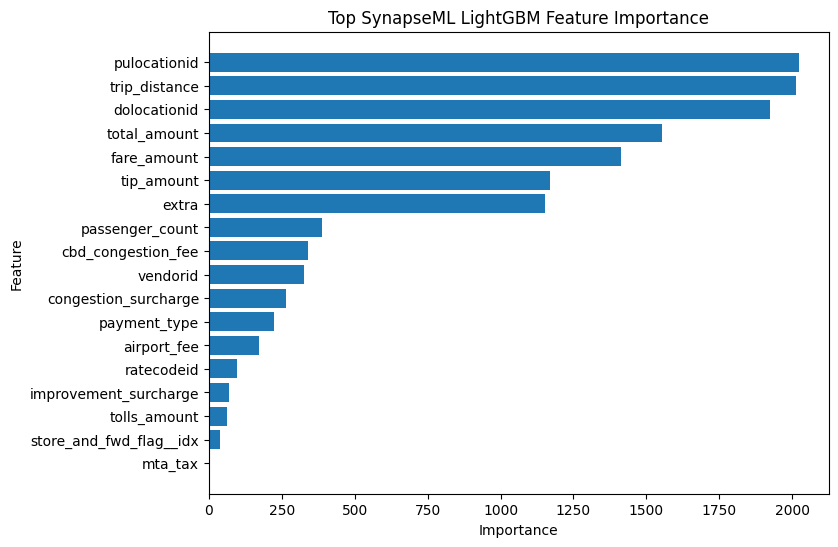

In [28]:
import matplotlib.pyplot as plt

plot_df = importance_df.dropna().head(20).sort_values("importance")

if len(plot_df) > 0:
    plt.figure(figsize=(8, 6))
    plt.barh(plot_df["feature"], plot_df["importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Top SynapseML LightGBM Feature Importance")
    plt.show()
else:
    print("Native feature importance not available or empty.")


In [29]:
def compute_top_shap_from_predictions(pred_df, feature_cols, shap_col="featuresShap", top_n=20, sample_size=None, seed=42):
    """Tính mean(|SHAP|) cho từng feature từ prediction DataFrame."""
    if shap_col not in pred_df.columns:
        raise ValueError(
            f"Column {shap_col!r} không tồn tại. "
            "Hãy bật RUN_FINAL_SHAP=True hoặc estimator phải có featuresShapCol."
        )

    shap_source_df = pred_df

    if sample_size is not None:
        total = pred_df.count()
        if total > sample_size:
            frac = min(1.0, float(sample_size) / float(total) * 1.5)
            shap_source_df = pred_df.sample(False, frac, seed=seed).limit(int(sample_size))

    shap_df = shap_source_df.withColumn("shap_array", vector_to_array(shap_col))
    shap_size = shap_df.select(F.size("shap_array").alias("shap_size")).first()["shap_size"]

    shap_long_df = shap_df.select(
        F.posexplode("shap_array").alias("feature_index", "shap_value")
    )

    # Một số version có bias/base value ở cuối vector SHAP. Nếu có, bỏ phần đó.
    if shap_size == len(feature_cols) + 1:
        shap_long_df = shap_long_df.filter(F.col("feature_index") < len(feature_cols))

    feature_mapping_df = spark.createDataFrame(
        [(i, name) for i, name in enumerate(feature_cols)],
        ["feature_index", "feature"],
    )

    shap_all_df = (
        shap_long_df
        .groupBy("feature_index")
        .agg(F.avg(F.abs("shap_value")).alias("mean_abs_shap"))
        .join(F.broadcast(feature_mapping_df), on="feature_index", how="left")
        .orderBy(F.desc("mean_abs_shap"))
    )

    return shap_all_df.limit(top_n), shap_all_df


if RUN_FINAL_SHAP and final_test_pred_df is not None and "featuresShap" in final_test_pred_df.columns:
    shap_top_df_spark, shap_all_df_spark = compute_top_shap_from_predictions(
        pred_df=final_test_pred_df,
        feature_cols=feature_pipeline.feature_cols_,
        shap_col="featuresShap",
        top_n=20,
        sample_size=SHAP_SAMPLE_SIZE,
        seed=RANDOM_STATE,
    )

    shap_top_pdf = shap_top_df_spark.toPandas()
    shap_path = f"{OUTPUT_DIR}/final_synapseml_shap_top_features.csv"
    shap_top_pdf.to_csv(shap_path, index=False)

    print("Saved:", shap_path)
    display(shap_top_pdf)
else:
    shap_top_pdf = pd.DataFrame(columns=["feature_index", "mean_abs_shap", "feature"])
    print("Final SHAP skipped. Set RUN_FINAL_SHAP=True to compute SynapseML featuresShap.")


26/05/11 23:46:26 WARN DAGScheduler: Broadcasting large task binary with size 1766.0 KiB
26/05/11 23:46:27 WARN DAGScheduler: Broadcasting large task binary with size 1771.0 KiB
26/05/11 23:46:28 WARN DAGScheduler: Broadcasting large task binary with size 1771.0 KiB
26/05/11 23:46:30 WARN DAGScheduler: Broadcasting large task binary with size 1772.7 KiB
26/05/11 23:46:32 WARN DAGScheduler: Broadcasting large task binary with size 1804.3 KiB


Saved: /opt/spark/workspace/output/synapseml_experiment_silver_yellow_tripdata/final_synapseml_shap_top_features.csv


,feature_index,mean_abs_shap,feature
0,5,0.472800,extra
1,13,0.449849,cbd_congestion_fee
2,3,0.137151,pulocationid
3,14,0.115791,vendorid
4,4,0.089018,dolocationid
5,11,0.079565,congestion_surcharge
6,10,0.073812,total_amount
7,1,0.072904,trip_distance
8,2,0.062796,fare_amount
9,0,0.049875,passenger_count


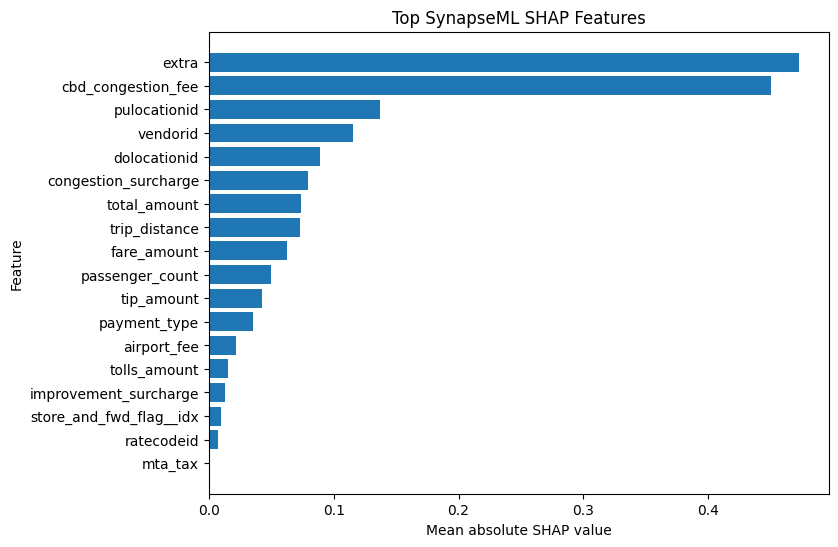

In [30]:
if len(shap_top_pdf) > 0:
    plot_df = shap_top_pdf.sort_values("mean_abs_shap")

    plt.figure(figsize=(8, 6))
    plt.barh(plot_df["feature"], plot_df["mean_abs_shap"])
    plt.xlabel("Mean absolute SHAP value")
    plt.ylabel("Feature")
    plt.title("Top SynapseML SHAP Features")
    plt.show()
else:
    print("No SHAP plot because SHAP was skipped or unavailable.")


## 21. Optional: Synthetic anomaly experiment

Phần này chỉ chạy khi `RUN_SYNTHETIC_EXPERIMENTS=True`. Mục tiêu là kiểm tra detector có nhạy hơn khi ta cố tình inject anomaly vào target batch hay không.


In [ ]:
ANOMALY_LEVELS = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75]
ANOMALY_RANDOM_STATE = 2025


def inject_synthetic_anomalies_spark(target_df, anomaly_fraction=0.30, random_state=42):
    """
    Inject anomaly đơn giản vào một phần target rows.

    Đây chỉ là synthetic test, không dùng để clean dữ liệu thật.
    """
    data = (
        target_df
        .withColumn("_r_anom", F.rand(int(random_state)))
        .withColumn("synthetic_anomaly", (F.col("_r_anom") < float(anomaly_fraction)).cast("int"))
        .withColumn("_anom_group", (F.rand(int(random_state) + 1) * 5).cast("int"))
    )

    is_anom = F.col("synthetic_anomaly") == 1

    if "trip_distance" in data.columns:
        data = data.withColumn(
            "trip_distance",
            F.when(is_anom & (F.col("_anom_group") == 0), F.col("trip_distance") * F.lit(5.0))
             .otherwise(F.col("trip_distance"))
        )

    if "total_amount" in data.columns:
        data = data.withColumn(
            "total_amount",
            F.when(is_anom & (F.col("_anom_group") == 1), F.col("total_amount") * F.lit(4.0))
             .otherwise(F.col("total_amount"))
        )

    if "fare_amount" in data.columns:
        data = data.withColumn(
            "fare_amount",
            F.when(is_anom & (F.col("_anom_group") == 2), F.col("fare_amount") * F.lit(4.0))
             .otherwise(F.col("fare_amount"))
        )

    if "store_and_fwd_flag" in data.columns:
        data = data.withColumn(
            "store_and_fwd_flag",
            F.when(is_anom & (F.col("_anom_group") == 3), F.lit("ANOM"))
             .otherwise(F.col("store_and_fwd_flag"))
        )

    for loc_col in ["pulocationid", "dolocationid"]:
        if loc_col in data.columns:
            data = data.withColumn(
                loc_col,
                F.when(is_anom & (F.col("_anom_group") == 4), F.lit(999))
                 .otherwise(F.col(loc_col))
            )

    return data.drop("_r_anom", "_anom_group")


def train_synapseml_on_work_df(batch_work_df, synapseml_params, random_state=42, shap_col=None, return_artifacts=False):
    """
    Train/evaluate trọn gói trên một work_df bất kỳ.

    Dùng cho:
    - Synthetic experiments.
    - Batch monitoring loop.
    """
    local_split_df = None
    local_lgbm_train_df = None
    local_train_features_df = None
    local_valid_features_df = None
    local_test_features_df = None
    local_test_pred_df = None

    try:
        local_train_raw_df, local_valid_raw_df, local_test_raw_df, local_split_df = stratified_split_sklearn_like_spark(
            input_df=batch_work_df,
            label_col="label",
            test_size=TEST_SIZE,
            valid_size=VALID_SIZE,
            seed=random_state,
            cache_result=True,
            return_split_df=True,
        )

        local_pipeline = SparkTaxiFeaturePipeline(
            categorical_cols=CATEGORICAL_COLS,
            numeric_cols=NUMERIC_COLS,
            exclude_cols=EXCLUDE_COLS,
            label_col="label",
        ).fit(local_train_raw_df)

        local_train_features_df = local_pipeline.transform(local_train_raw_df).select("features", "label").persist(StorageLevel.MEMORY_AND_DISK)
        local_valid_features_df = local_pipeline.transform(local_valid_raw_df).select("features", "label").persist(StorageLevel.MEMORY_AND_DISK)
        local_test_features_df = local_pipeline.transform(local_test_raw_df).select("features", "label").persist(StorageLevel.MEMORY_AND_DISK)

        local_train_features_df.count()
        local_valid_features_df.count()
        local_test_features_df.count()

        local_lgbm_train_df = build_lgbm_train_df(
            train_df=local_train_features_df,
            valid_df=local_valid_features_df,
            num_partitions=LGBM_NUM_PARTITIONS,
            persist=True,
        )

        estimator = build_synapseml_lgbm_classifier(
            synapseml_params=synapseml_params,
            categorical_slot_indexes=local_pipeline.categorical_slot_indexes_,
            shap_col=shap_col,
            validation_col="is_validation",
        )

        start = time.time()
        model = estimator.fit(local_lgbm_train_df)
        fit_seconds = time.time() - start

        valid_auc, _ = evaluate_auc(model, local_valid_features_df.select("features", "label"), return_predictions=False)
        test_auc, local_test_pred_df = evaluate_auc(
            model,
            local_test_features_df.select("features", "label"),
            return_predictions=return_artifacts,
            persist_predictions=return_artifacts,
        )

        result = {
            "valid_auc": float(valid_auc),
            "test_auc": float(test_auc),
            "best_iteration": safe_get_best_iteration(model),
            "fit_seconds": float(fit_seconds),
            "feature_count": len(local_pipeline.feature_cols_),
        }

        artifacts = None
        if return_artifacts:
            artifacts = {
                "model": model,
                "pipeline": local_pipeline,
                "test_pred_df": local_test_pred_df,
                "feature_cols": local_pipeline.feature_cols_,
            }

        return result, artifacts

    finally:
        if not return_artifacts:
            for obj in [
                local_test_pred_df,
                local_lgbm_train_df,
                local_train_features_df,
                local_valid_features_df,
                local_test_features_df,
                local_split_df,
            ]:
                try:
                    if obj is not None:
                        obj.unpersist()
                except Exception:
                    pass
        gc.collect()


if RUN_SYNTHETIC_EXPERIMENTS:
    synthetic_results = []

    for frac in ANOMALY_LEVELS:
        print("Running synthetic anomaly fraction:", frac)

        temp_positive = inject_synthetic_anomalies_spark(
            positive_df,
            anomaly_fraction=frac,
            random_state=ANOMALY_RANDOM_STATE,
        )

        temp_negative = negative_df.withColumn("synthetic_anomaly", F.lit(0))

        temp_work_df = (
            temp_positive
            .unionByName(temp_negative, allowMissingColumns=True)
            .repartition(SPARK_SQL_SHUFFLE_PARTITIONS)
            .persist(StorageLevel.MEMORY_AND_DISK)
        )
        temp_work_df.count()

        try:
            result, _ = train_synapseml_on_work_df(
                temp_work_df,
                synapseml_params=selected_synapseml_params,
                random_state=RANDOM_STATE,
                shap_col=None,
                return_artifacts=False,
            )

            result["anomaly_fraction"] = float(frac)
            result["n_rows"] = int(temp_work_df.count())
            result["n_synthetic_anomaly"] = int(temp_work_df.filter(F.col("synthetic_anomaly") == 1).count())
            synthetic_results.append(result)

            print(result)
        finally:
            temp_work_df.unpersist()

    synthetic_df = pd.DataFrame(synthetic_results)
    synthetic_path = f"{OUTPUT_DIR}/synthetic_anomaly_sweep.csv"
    synthetic_df.to_csv(synthetic_path, index=False)

    print("Saved:", synthetic_path)
    display(synthetic_df)
else:
    print("Synthetic experiments skipped. Set RUN_SYNTHETIC_EXPERIMENTS=True to run.")


## 22. Optional: Batch AUC monitoring

Phần này chạy nhiều target batches liên tiếp để tạo chuỗi AUC. Chỉ chạy khi `RUN_BATCH_MONITORING=True`.


In [ ]:
def build_dataset_for_target_batch_spark(
    source_df,
    target_processing_hour,
    min_rows_per_group=MIN_ROWS_PER_GROUP,
    max_rows_per_group=TARGET_SAMPLE_PER_GROUP,
    random_state=RANDOM_STATE,
):
    """Build work_df cho một target batch cụ thể."""
    positive = sample_by_processing_hour_spark(
        source_df=source_df,
        processing_hour=target_processing_hour,
        label=1,
        max_rows=max_rows_per_group,
        random_state=random_state,
        oversample_factor=OVERSAMPLE_FACTOR,
    )

    positive_rows = positive.count()
    if positive_rows < min_rows_per_group:
        return None, {
            "status": "skipped",
            "reason": "positive_rows_too_few",
            "target_processing_date_hour": str(target_processing_hour),
            "positive_rows": int(positive_rows),
        }

    comparison_hours = get_comparison_processing_hours(target_processing_hour)

    negative_parts = []
    negative_info = []

    for i, compare_hour in enumerate(comparison_hours):
        part = sample_by_processing_hour_spark(
            source_df=source_df,
            processing_hour=compare_hour,
            label=0,
            max_rows=max_rows_per_group,
            random_state=random_state + i + 100,
            oversample_factor=OVERSAMPLE_FACTOR,
        )

        rows = part.count()
        negative_info.append({"comparison_hour": str(compare_hour), "rows": int(rows)})

        if rows >= min_rows_per_group:
            negative_parts.append(part)

    if len(negative_parts) == 0:
        return None, {
            "status": "skipped",
            "reason": "negative_rows_too_few",
            "target_processing_date_hour": str(target_processing_hour),
            "positive_rows": int(positive_rows),
            "negative_info": negative_info,
        }

    negative = negative_parts[0]
    for p in negative_parts[1:]:
        negative = negative.unionByName(p, allowMissingColumns=True)

    work = positive.unionByName(negative, allowMissingColumns=True)
    work = work.repartition(SPARK_SQL_SHUFFLE_PARTITIONS).persist(StorageLevel.MEMORY_AND_DISK)
    work.count()

    label_counts = {
        float(r["label"]): int(r["count"])
        for r in work.groupBy("label").count().collect()
    }

    meta = {
        "status": "ok",
        "target_processing_date_hour": str(target_processing_hour),
        "positive_rows": int(label_counts.get(1.0, 0)),
        "negative_rows": int(label_counts.get(0.0, 0)),
        "total_rows": int(sum(label_counts.values())),
        "comparison_hours": [str(h) for h in comparison_hours],
        "negative_info": negative_info,
    }

    return work, meta


In [ ]:
if RUN_BATCH_MONITORING:
    target_batch_list = pd.date_range(start=BATCH_START, end=BATCH_END, freq=BATCH_FREQ).tolist()

    print("Number of target batches:", len(target_batch_list))
    print("First target batch:", target_batch_list[0])
    print("Last target batch :", target_batch_list[-1])

    batch_auc_results = []

    for i, batch_hour in enumerate(target_batch_list):
        print("\n" + "=" * 80)
        print(f"[{i+1}/{len(target_batch_list)}] Target batch: {batch_hour}")

        batch_df = None
        artifacts = None

        try:
            batch_df, meta = build_dataset_for_target_batch_spark(
                source_df=df_raw,
                target_processing_hour=batch_hour,
                random_state=RANDOM_STATE + i,
            )

            if meta.get("status") != "ok":
                print("Skipped:", meta)
                batch_auc_results.append(meta)
                continue

            need_shap = bool(RUN_BATCH_SHAP)
            result, artifacts = train_synapseml_on_work_df(
                batch_df,
                synapseml_params=selected_synapseml_params,
                random_state=RANDOM_STATE + i,
                shap_col=("featuresShap" if need_shap else None),
                return_artifacts=need_shap,
            )

            row = {**meta, **result}
            batch_auc_results.append(row)
            print("Result:", row)

            # Optional SHAP per batch nếu cần.
            if need_shap and artifacts is not None:
                shap_top_df_spark, _ = compute_top_shap_from_predictions(
                    artifacts["test_pred_df"],
                    feature_cols=artifacts["feature_cols"],
                    shap_col="featuresShap",
                    top_n=10,
                    sample_size=1000,
                    seed=RANDOM_STATE + i,
                )
                shap_top_pdf = shap_top_df_spark.toPandas()
                shap_top_pdf["target_processing_date_hour"] = str(batch_hour)
                display(shap_top_pdf)

        except Exception as e:
            print("Failed:", repr(e))
            batch_auc_results.append({
                "status": "failed",
                "target_processing_date_hour": str(batch_hour),
                "reason": repr(e),
            })

        finally:
            try:
                if batch_df is not None:
                    batch_df.unpersist()
            except Exception:
                pass
            gc.collect()

    auc_series_df = pd.DataFrame(batch_auc_results)
    auc_series_path = f"{OUTPUT_DIR}/batch_auc_series.csv"
    auc_series_df.to_csv(auc_series_path, index=False)

    print("Saved:", auc_series_path)
    display(auc_series_df)
else:
    auc_series_df = pd.DataFrame()
    print("Batch monitoring skipped. Set RUN_BATCH_MONITORING=True to run.")


## 23. Empirical p-value for AUC monitoring

Nếu đã có chuỗi AUC theo batch, ta dùng empirical p-value để xem AUC hiện tại có thuộc vùng cao bất thường so với lịch sử trước đó hay không.


In [ ]:
def add_empirical_auc_anomaly_score(
    auc_df,
    auc_col="test_auc",
    time_col="target_processing_date_hour",
    min_history_points=20,
    rolling_window=None,
    alpha=0.05,
):
    """
    Tính empirical p-value theo lịch sử trước thời điểm hiện tại.

    Công thức:
    p_value = (số AUC lịch sử >= AUC hiện tại + 1) / (số điểm lịch sử + 1)

    Nếu p_value <= alpha, AUC hiện tại nằm ở vùng cao bất thường so với lịch sử.
    """
    data = auc_df.copy()

    if data.empty or auc_col not in data.columns:
        return data

    data = data.sort_values(time_col).reset_index(drop=True)

    p_values = []
    percentile_ranks = []
    history_means = []
    history_medians = []
    history_qs = []
    history_sizes = []
    anomaly_flags = []
    anomaly_reasons = []

    for i, row in data.iterrows():
        current_auc = row.get(auc_col, np.nan)
        history = data.loc[:i-1, auc_col].dropna()

        if rolling_window is not None:
            history = history.tail(int(rolling_window))

        history_size = len(history)
        history_sizes.append(history_size)

        if history_size < min_history_points or pd.isna(current_auc):
            p_values.append(np.nan)
            percentile_ranks.append(np.nan)
            history_means.append(np.nan)
            history_medians.append(np.nan)
            history_qs.append(np.nan)
            anomaly_flags.append(False)
            anomaly_reasons.append("warmup_not_enough_history")
            continue

        p_value = (np.sum(history >= current_auc) + 1) / (history_size + 1)
        percentile_rank = (np.sum(history <= current_auc) + 1) / (history_size + 1)

        history_mean = history.mean()
        history_median = history.median()
        history_q = history.quantile(1 - alpha)

        is_anomaly = p_value <= alpha

        p_values.append(float(p_value))
        percentile_ranks.append(float(percentile_rank))
        history_means.append(float(history_mean))
        history_medians.append(float(history_median))
        history_qs.append(float(history_q))
        anomaly_flags.append(bool(is_anomaly))

        if is_anomaly:
            anomaly_reasons.append(f"auc_is_in_top_{int(alpha * 100)}pct_tail_of_history")
        else:
            anomaly_reasons.append("normal_vs_history")

    q_col = f"history_auc_q{int((1-alpha)*100)}"
    data["history_size"] = history_sizes
    data["history_auc_mean"] = history_means
    data["history_auc_median"] = history_medians
    data[q_col] = history_qs
    data["auc_empirical_p_value"] = p_values
    data["auc_percentile_rank"] = percentile_ranks
    data["is_auc_anomaly"] = anomaly_flags
    data["auc_anomaly_reason"] = anomaly_reasons

    return data


if len(auc_series_df) > 0:
    auc_monitoring_df = add_empirical_auc_anomaly_score(
        auc_series_df,
        auc_col="test_auc",
        time_col="target_processing_date_hour",
        min_history_points=MIN_HISTORY_POINTS,
        rolling_window=ROLLING_WINDOW,
        alpha=ALPHA,
    )

    auc_monitoring_path = f"{OUTPUT_DIR}/batch_auc_empirical_pvalue_monitoring.csv"
    auc_monitoring_df.to_csv(auc_monitoring_path, index=False)

    print("Saved:", auc_monitoring_path)
    display(auc_monitoring_df)
else:
    print("No AUC series available. Run batch monitoring first.")


In [ ]:
if "auc_monitoring_df" in globals() and len(auc_monitoring_df) > 0:
    plot_df = auc_monitoring_df.copy()
    plot_df["target_processing_date_hour"] = pd.to_datetime(plot_df["target_processing_date_hour"])
    plot_df = plot_df.sort_values("target_processing_date_hour")

    plt.figure(figsize=(12, 5))
    plt.plot(plot_df["target_processing_date_hour"], plot_df["test_auc"], marker="o", label="test_auc")

    q_col = f"history_auc_q{int((1-ALPHA)*100)}"
    if q_col in plot_df.columns:
        plt.plot(plot_df["target_processing_date_hour"], plot_df[q_col], linestyle="--", label=q_col)

    if "is_auc_anomaly" in plot_df.columns:
        anomalies = plot_df[plot_df["is_auc_anomaly"] == True]
        if len(anomalies) > 0:
            plt.scatter(anomalies["target_processing_date_hour"], anomalies["test_auc"], s=80, label="anomaly")

    plt.xlabel("target_processing_date_hour")
    plt.ylabel("AUC")
    plt.title("Batch AUC Monitoring")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No AUC monitoring plot.")


## 24. Cleanup

Chạy cell này sau khi đã lưu xong kết quả để giải phóng cache Spark.


In [ ]:
# Chỉ cleanup khi bạn đã hoàn tất train/evaluate/monitoring.
for obj_name in [
    "final_test_pred_df",
    "lgbm_train_df",
    "train_features_df",
    "valid_features_df",
    "test_features_df",
    "main_split_df",
    "work_df",
    "df_raw",
]:
    try:
        obj = globals().get(obj_name)
        if obj is not None:
            obj.unpersist()
            print("Unpersisted:", obj_name)
    except Exception as e:
        print("Skip cleanup for", obj_name, ":", repr(e))

gc.collect()
print("Cleanup completed.")
